# Full-dataset pooling validation, with paired ESM2 additions

Eighteen from-scratch runs on the full eligible cohort of 150,938 graphs, all sharing the frozen 125-target split:

- **`full_pooling_validation/`** — twelve control runs, a $2\times2\times3$ design over pooling (whole graph; whole graph $+$ interface), the DockQ weighting exponent $\alpha$ (0.5; 0.75) and seed (7, 17, 27).
- **`full_pooling_esm_validation/`** — six ESM2 layer-33 additions, one per pooling $\times$ seed at $\alpha=0.75$, each recorded in its matrix with an explicit `matched_control`.

This analysis uses **validation predictions and loss histories only**; the test split stays sealed, and the runs were launched with `--no-test-evaluation`. The primary metric is unweighted validation DockQ MSE, which is also the checkpoint-selection criterion, so the reported number for each run is the minimum over 50 epochs and is optimistic by construction.

Figures use LaTeX Computer Modern, large labels, full borders and no titles. Error bars and bands are **sample standard deviation across three seeds**, not confidence intervals. Three seeds and ten validation targets are a small basis for inference; treat rankings as exploratory.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

GATE=Path.cwd() if (Path.cwd()/'full_pooling_validation').is_dir() else Path.cwd()/'gate_run'
CONTROL_ROOT=GATE/'full_pooling_validation'
ESM_ROOT=GATE/'full_pooling_esm_validation'
EXPORT=GATE/'full_pooling_validation_analysis'; EXPORT.mkdir(exist_ok=True)
control_matrix=json.loads((CONTROL_ROOT/'matrix.json').read_text())
esm_matrix=json.loads((ESM_ROOT/'matrix.json').read_text())
SEEDS=[7,17,27]; POOLINGS=['all','combined']; EXPONENTS=[.5,.75]
POOL_LABEL={'all':'Whole graph','combined':'Whole graph $+$ interface'}
POOL_SHORT={'all':'Whole\ngraph','combined':'Whole graph\n$+$ interface'}
POOL_TICK={'all':'Whole\ngraph','combined':'Combined'}
POOL_PLAIN={'all':'whole-graph','combined':'combined (whole graph + interface)'}
CONFIGS=[(p,a) for p in POOLINGS for a in EXPONENTS]
CONFIG_LABEL={(p,a):f'{POOL_LABEL[p]}, $\\alpha={a:g}$' for p,a in CONFIGS}
CONFIG_PLAIN={(p,a):f'{POOL_PLAIN[p]} pooling, alpha={a:g}' for p,a in CONFIGS}
CONFIG_COLOR={('all',.5):'#0072B2',('all',.75):'#56B4E9',('combined',.5):'#009E73',('combined',.75):'#66C2A5'}
ESM_COLOR='#D55E00'; CONTROL_COLOR='black'
EDGES=np.array([.2,.4,.6,.8],dtype=np.float32)
BIN_LABEL=['0--0.2','0.2--0.4','0.4--0.6','0.6--0.8','0.8--1.0']
mpl.rcParams.update({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
    'mathtext.fontset':'cm','axes.labelsize':23,'xtick.labelsize':17,'ytick.labelsize':17,
    'legend.fontsize':17,'axes.spines.top':True,'axes.spines.right':True,'axes.linewidth':1.1})
def save(fig,name):
    fig.savefig(EXPORT/(name+'.pdf'),bbox_inches='tight')
    fig.savefig(EXPORT/(name+'.png'),dpi=180,bbox_inches='tight')
    plt.show()
def rho(y,p):
    return float(spearmanr(y,p).statistic) if y.nunique()>1 and p.nunique()>1 else np.nan
def options(argv):
    result={}; i=0
    while i<len(argv):
        key=argv[i]; i+=1
        value=True
        if i<len(argv) and not argv[i].startswith('--'): value=argv[i]; i+=1
        result[key]=value
    return result
print(f'{len(control_matrix["runs"])} control runs, {len(esm_matrix["runs"])} ESM2 runs; '
      f'cohort {control_matrix["eligible_models"]:,} eligible of {control_matrix["raw_models"]:,} raw models.')

12 control runs, 6 ESM2 runs; cohort 150,938 eligible of 189,710 raw models.


## Audit the completed runs

Nothing is compared until the runs are shown to be comparable. The checks below require: the declared $2\times2\times3$ and $2\times3$ designs with no duplicates; every run differing from a common reference only in its declared factors, output path and ESM flags; fifty finite epochs with the fixed loss weights; no test evaluation; identical training label distributions within an exponent; and the same validation graphs, names and labels in all eighteen prediction files.

The last check is the important one for every paired statement later: identical `(target_id, graph_name, true_target)` frames mean the runs are being compared on precisely the same graphs, so differences cannot come from cohort drift.

In [2]:
runs={}
for root,matrix,arm in [(CONTROL_ROOT,control_matrix,'Control'),(ESM_ROOT,esm_matrix,'ESM2')]:
    assert matrix['validation_only'] and matrix['apbs_enabled'] is False and matrix['full_dataset']
    assert matrix['eligible_models']==control_matrix['eligible_models']
    for r in matrix['runs']:
        path=root/Path(r['output']).name
        detail=r['full_validation']
        assert detail['reconstruction_lambda']==1
        runs[path.name]=dict(arm=arm, path=path, seed=r['seed'], pooling=detail['pooling'],
            exponent=detail['exponent'], esm=bool(detail.get('esm',False)),
            control=Path(r['matched_control']).name if 'matched_control' in r else None,
            argv=r['argv'])
assert esm_matrix['esm_layer']==33 and esm_matrix['esm_width']==1280 and esm_matrix['esm_projection_width']==64
design=pd.DataFrame([{k:v for k,v in r.items() if k in ('arm','seed','pooling','exponent','esm')} for r in runs.values()])
assert not design.duplicated(['arm','seed','pooling','exponent']).any()
assert sorted(design[design.arm=='Control'].groupby(['pooling','exponent']).seed.nunique().unique())==[3]
assert set(design[design.arm=='ESM2'].exponent)=={.75} and len(design[design.arm=='ESM2'])==6
reference=options(runs['full_all_alpha0.75_seed7']['argv'])
DECLARED={'--pooling','--dockq-weight-exponent','--seed','--output-dir','--use-esm','--esm-sidecar-dir','--esm-projection-dim'}
for name,r in runs.items():
    opts=options(r['argv'])
    differing={k for k in set(reference)|set(opts) if opts.get(k)!=reference.get(k)}
    assert differing<=DECLARED, (name,differing-DECLARED)
    assert opts['--epochs']=='50' and opts['--checkpoint-metric']=='target_mse'
    assert '--no-test-evaluation' in opts and opts.get('--dropout')=='0.3'
    assert opts['--lr']=='3e-4' and opts['--batch-size']=='16' and opts['--lr-schedule']=='cosine'
    assert (opts.get('--use-esm') is True)==r['esm']
print(f'{len(runs)} runs; the only argument differences from the reference run are '
      +', '.join(sorted(DECLARED))+'.')
display(design.groupby(['arm','pooling','exponent']).size().rename('runs').to_frame())

18 runs; the only argument differences from the reference run are --dockq-weight-exponent, --esm-projection-dim, --esm-sidecar-dir, --output-dir, --pooling, --seed, --use-esm.


runs
arm     pooling  exponent      
Control all      0.50         3
                 0.75         3
        combined 0.50         3
                 0.75         3
ESM2    all      0.75         3
        combined 0.75         3

In [3]:
split=json.loads((CONTROL_ROOT/'target_splits.json').read_text())['splits']
validation_targets=set(split['val']['targets'])
assert not validation_targets & (set(split['train']['targets'])|set(split['test']['targets']))
identity=None; weighting={}
for name,r in runs.items():
    h=pd.read_csv(r['path']/'loss_history.csv')
    assert h.epoch.tolist()==list(range(1,51)), name
    assert np.isfinite(h.filter(regex='^(train_|val_)').to_numpy()).all(), name
    assert h.filter(regex='^test_').isna().all().all(), name              # test split untouched
    for term,weight in [('node_mse',1),('edge_attr_mse',1),('edge_presence_bce',.1),('target_mse',1)]:
        assert np.allclose(h['weight_'+term],weight), name
    f=pd.read_csv(r['path']/'validation_predictions.csv').sort_values(['target_id','graph_name']).reset_index(drop=True)
    assert len(f)==split['val']['sample_count'] and set(f.target_id)==validation_targets, name
    assert not f.duplicated(['target_id','graph_name']).any(), name
    assert np.isfinite(f[['true_target','predicted_target']]).all().all(), name
    assert f.true_target.between(0,1).all(), name
    keys=f[['target_id','graph_name','true_target']]
    if identity is None: identity=keys
    else: pd.testing.assert_frame_equal(identity,keys)                    # same graphs and labels everywhere
    pooled=float(np.mean((f.true_target-f.predicted_target)**2))
    assert np.isclose(pooled,h.val_target_mse.min(),rtol=1e-4,atol=1e-7), name   # exported checkpoint is the selected one
    r['history']=h; r['predictions']=f; r['pooled_mse']=pooled
    r['best_epoch']=int(h.loc[h.val_target_mse.idxmin()].epoch)
    distribution=json.loads((r['path']/'dockq_training_distribution.json').read_text())
    weighting.setdefault(r['exponent'],distribution)
    assert distribution==weighting[r['exponent']], name                   # identical training weighting within an exponent
    assert distribution['source']=='training labels only'
    r['epoch_metrics']=[json.loads(line) for line in (r['path']/'dockq_epoch_metrics.jsonl').read_text().splitlines()]
    assert len(r['epoch_metrics'])==50, name
print(f'All 18 runs completed 50 epochs with fixed loss weights and no test evaluation.')
print(f'Identical validation cohort in every run: {len(identity):,} graphs across '
      f'{identity.target_id.nunique()} targets, with identical DockQ labels.')
print('Each exported checkpoint reproduces its run\'s minimum validation DockQ MSE.')
print(f'Training cohort: {sum(weighting[.5]["counts"]):,} graphs; validation '
      f'{split["val"]["sample_count"]:,}; test {split["test"]["sample_count"]:,} (sealed).')

All 18 runs completed 50 epochs with fixed loss weights and no test evaluation.
Identical validation cohort in every run: 11,325 graphs across 10 targets, with identical DockQ labels.
Each exported checkpoint reproduces its run's minimum validation DockQ MSE.
Training cohort: 109,147 graphs; validation 11,325; test 30,466 (sealed).


### Parameter counts

The comparisons are not parameter-matched, and it is worth quantifying by how much before reading any difference as an effect of pooling or of ESM2. Combined pooling concatenates whole-graph and interface-node mean/max embeddings before the graph projector; ESM2 adds a LayerNorm/linear/SiLU encoder input that projects 1280 residue features to 64.

In [4]:
parameters={}
for name,r in runs.items():
    state=torch.load(r['path']/'gate_model.pt',map_location='cpu',weights_only=False)
    state=state.get('model_state_dict',state) if isinstance(state,dict) else state
    parameters[name]=int(sum(v.numel() for v in state.values() if hasattr(v,'numel')))
    r['parameters']=parameters[name]
size=pd.DataFrame([dict(arm=r['arm'],pooling=r['pooling'],parameters=r['parameters']) for r in runs.values()])
size=size.groupby(['arm','pooling']).parameters.agg(['nunique','first']).rename(columns={'first':'parameters'})
assert (size['nunique']==1).all()          # seeds within a configuration share one architecture
size=size[['parameters']]
base=size.loc[('Control','all'),'parameters']
size['vs_whole_graph_control']=size.parameters-base
display(size)
print(f'Combined pooling adds {size.loc[("Control","combined"),"parameters"]-base:,} parameters; '
      f'ESM2 adds {size.loc[("ESM2","all"),"parameters"]-base:,} on top of whole-graph pooling.')

parameters  vs_whole_graph_control
arm     pooling                                     
Control all           250012                       0
        combined      254108                    4096
ESM2    all           367324                  117312
        combined      371420                  121408

Combined pooling adds 4,096 parameters; ESM2 adds 117,312 on top of whole-graph pooling.


## The DockQ weighting the exponent produces

Range weights come from training labels only, with mean-one normalization and a maximum weight ratio of three. The exponent is the only thing that differs between the $\alpha=0.5$ and $\alpha=0.75$ arms, so it is worth seeing exactly how much reweighting it buys.

In [5]:
weight_table=pd.DataFrame({'graphs':weighting[.5]['counts']},index=BIN_LABEL)
weight_table['share_pct']=100*weight_table.graphs/weight_table.graphs.sum()
for a in EXPONENTS: weight_table[f'weight_alpha{a:g}']=weighting[a]['weights']
weight_table['weight_change_pct']=100*(weight_table['weight_alpha0.75']/weight_table['weight_alpha0.5']-1)
weight_table.index.name='DockQ range'
weight_table.to_csv(EXPORT/'training_weighting.csv')
display(weight_table.round(3))
print(f'Training labels are dominated by the lowest range: {weight_table.share_pct.iloc[0]:.1f}% of '
      f'{weight_table.graphs.sum():,} training graphs fall in {BIN_LABEL[0]}.')
print(f'Raising the exponent from 0.5 to 0.75 pushes that range down by '
      f'{-weight_table.weight_change_pct.iloc[0]:.1f}% and lifts the others by up to '
      f'{weight_table.weight_change_pct.iloc[1:].max():.1f}%; the cap of '
      f'{weighting[.5]["max_weight_ratio"]:g} is not reached at either exponent.')

,graphs,share_pct,weight_alpha0.5,weight_alpha0.75,weight_change_pct
DockQ range,,,,,
0--0.2,51199,46.908,0.682,0.544,-20.165
0.2--0.4,16557,15.169,1.199,1.270,5.867
0.4--0.6,13517,12.384,1.327,1.478,11.375
0.6--0.8,14014,12.840,1.304,1.439,10.374
0.8--1.0,13860,12.698,1.311,1.451,10.679


Training labels are dominated by the lowest range: 46.9% of 109,147 training graphs fall in 0--0.2.
Raising the exponent from 0.5 to 0.75 pushes that range down by 20.2% and lifts the others by up to 11.4%; the cap of 3 is not reached at either exponent.


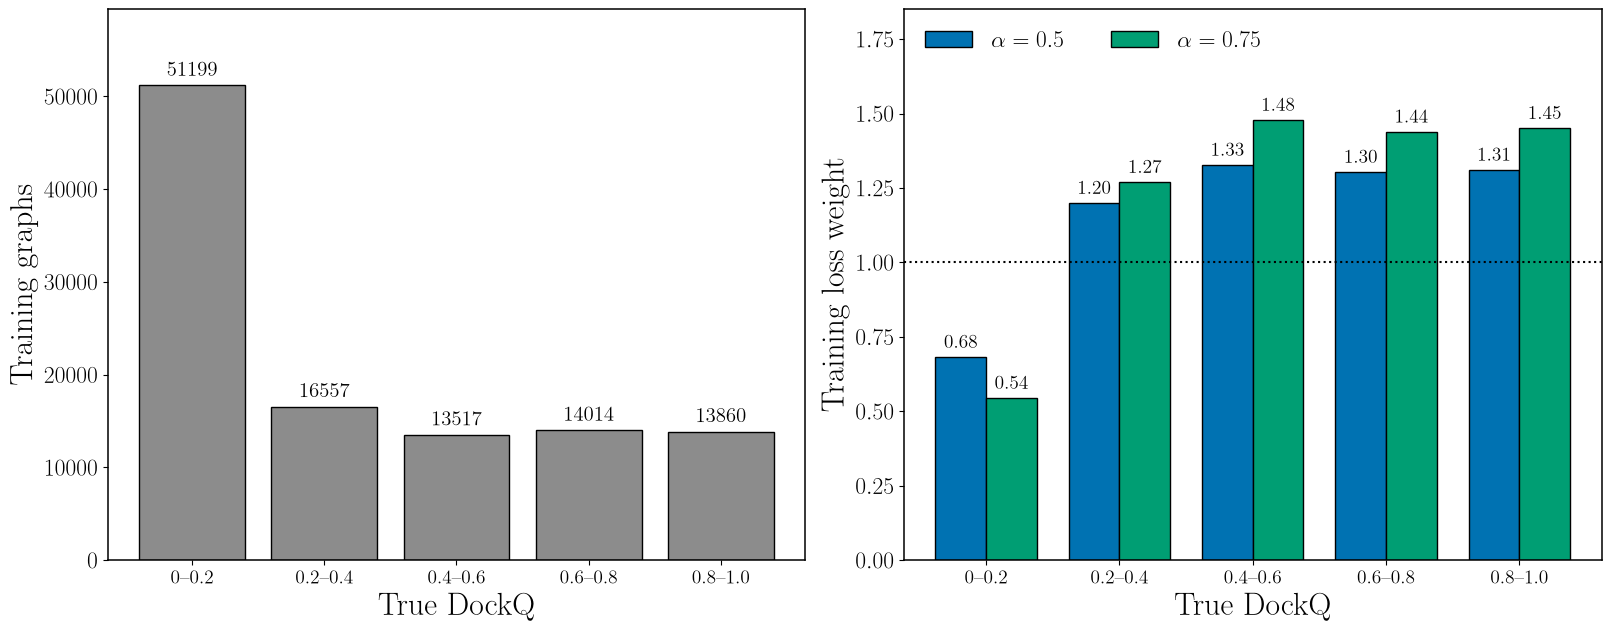

In [6]:
fig,axes=plt.subplots(1,2,figsize=(16,6.2),constrained_layout=True)
x=np.arange(5); width=.38
ax=axes[0]
bars=ax.bar(x,weight_table.graphs,color='0.55',edgecolor='black')
ax.bar_label(bars,fmt='%d',padding=4,fontsize=15)
ax.set_xticks(x,BIN_LABEL,fontsize=14); ax.set_xlabel('True DockQ'); ax.set_ylabel('Training graphs')
ax.set_ylim(0,weight_table.graphs.max()*1.16)
ax=axes[1]
for shift,a,color in [(-.5,.5,'#0072B2'),(.5,.75,'#009E73')]:
    bars=ax.bar(x+shift*width,weight_table[f'weight_alpha{a:g}'],width,color=color,edgecolor='black',
                label=f'$\\alpha={a:g}$')
    ax.bar_label(bars,fmt='%.2f',padding=4,fontsize=14)
ax.axhline(1,color='black',ls=':',lw=1.5)
ax.set_xticks(x,BIN_LABEL,fontsize=14); ax.set_xlabel('True DockQ'); ax.set_ylabel('Training loss weight')
ax.set_ylim(0,1.85); ax.legend(frameon=False,ncol=2,loc='upper left')
save(fig,'training_weighting')

## Control results: pooling and weighting

Each run contributes one number, the minimum validation DockQ MSE over its fifty epochs. Pooled MSE weights each validation graph equally; macro MSE and macro $\rho$ weight each of the ten validation targets equally. Spreads are the sample standard deviation over the three seeds.

In [7]:
rows=[]; target_rows=[]
for name,r in runs.items():
    f=r['predictions']
    per_target=[]
    for target,g in f.groupby('target_id'):
        entry=dict(run=name,arm=r['arm'],pooling=r['pooling'],exponent=r['exponent'],seed=r['seed'],
            target=target,n=len(g),mse=float(np.mean((g.true_target-g.predicted_target)**2)),
            rho=rho(g.true_target,g.predicted_target),bias=float(np.mean(g.predicted_target-g.true_target)))
        per_target.append(entry); target_rows.append(entry)
    h=r['history']
    rows.append(dict(run=name,arm=r['arm'],pooling=r['pooling'],exponent=r['exponent'],seed=r['seed'],
        mse=r['pooled_mse'],macro_mse=float(np.mean([e['mse'] for e in per_target])),
        macro_rho=float(np.nanmean([e['rho'] for e in per_target])),
        best_epoch=r['best_epoch'],final_mse=float(h.val_target_mse.iloc[-1]),
        train_mse_at_end=float(h.train_target_mse.iloc[-1]),
        rebound_pct=100*(h.val_target_mse.iloc[-1]/r['pooled_mse']-1),
        parameters=r['parameters']))
per_run=pd.DataFrame(rows).set_index('run')
per_target=pd.DataFrame(target_rows)
per_run.to_csv(EXPORT/'per_run.csv'); per_target.to_csv(EXPORT/'per_target.csv',index=False)
controls=per_run[per_run.arm=='Control']
summary=controls.groupby(['pooling','exponent']).agg(
    mean_mse=('mse','mean'),seed_sd=('mse','std'),macro_mse=('macro_mse','mean'),
    macro_rho=('macro_rho','mean'),rho_sd=('macro_rho','std'),
    mean_best_epoch=('best_epoch','mean'),mean_final_mse=('final_mse','mean'))
summary.to_csv(EXPORT/'control_summary.csv')
display(summary.round(5))
best=summary.mean_mse.idxmin(); worst=summary.mean_mse.idxmax()
print(f'Lowest mean validation MSE: {CONFIG_PLAIN[best]} at {summary.loc[best,"mean_mse"]:.5f} '
      f'+/- {summary.loc[best,"seed_sd"]:.5f} (seed SD).')
print(f'Highest: {CONFIG_PLAIN[worst]} at {summary.loc[worst,"mean_mse"]:.5f} '
      f'+/- {summary.loc[worst,"seed_sd"]:.5f}.')
print(f'Full spread across the four configurations is '
      f'{summary.mean_mse.max()-summary.mean_mse.min():.5f}, against a within-configuration seed SD of '
      f'{summary.seed_sd.min():.5f}--{summary.seed_sd.max():.5f}.')

mean_mse  seed_sd  macro_mse  macro_rho   rho_sd  \
pooling  exponent                                                     
all      0.50       0.07223  0.00379    0.06996    0.45850  0.05072   
         0.75       0.07533  0.00195    0.07287    0.43797  0.01593   
combined 0.50       0.07065  0.00194    0.06839    0.46446  0.06429   
         0.75       0.07162  0.00148    0.06947    0.45572  0.04142   

                   mean_best_epoch  mean_final_mse  
pooling  exponent                                   
all      0.50             16.00000         0.08434  
         0.75              3.00000         0.08346  
combined 0.50              5.00000         0.08751  
         0.75              1.66667         0.08210

Lowest mean validation MSE: combined (whole graph + interface) pooling, alpha=0.5 at 0.07065 +/- 0.00194 (seed SD).
Highest: whole-graph pooling, alpha=0.75 at 0.07533 +/- 0.00195.
Full spread across the four configurations is 0.00468, against a within-configuration seed SD of 0.00148--0.00379.


In [8]:
marginal=pd.concat([
    controls.groupby('pooling').agg(runs=('mse','size'),mean_mse=('mse','mean'),sd=('mse','std'),
        macro_rho=('macro_rho','mean')).rename(index=POOL_LABEL).rename_axis('factor'),
    controls.groupby('exponent').agg(runs=('mse','size'),mean_mse=('mse','mean'),sd=('mse','std'),
        macro_rho=('macro_rho','mean')).rename(index=lambda a:f'alpha={a:g}').rename_axis('factor')])
display(marginal.round(5))
paired_pooling=[]
for a in EXPONENTS:
    for s in SEEDS:
        pick=lambda p:controls[(controls.pooling==p)&(controls.exponent==a)&(controls.seed==s)].iloc[0]
        paired_pooling.append(dict(exponent=a,seed=s,delta=pick('combined').mse-pick('all').mse))
paired_pooling=pd.DataFrame(paired_pooling)
paired_exponent=[]
for p in POOLINGS:
    for s in SEEDS:
        pick=lambda a:controls[(controls.pooling==p)&(controls.exponent==a)&(controls.seed==s)].iloc[0]
        paired_exponent.append(dict(pooling=p,seed=s,delta=pick(.75).mse-pick(.5).mse))
paired_exponent=pd.DataFrame(paired_exponent)
paired_pooling.to_csv(EXPORT/'paired_pooling.csv',index=False)
paired_exponent.to_csv(EXPORT/'paired_exponent.csv',index=False)
print(f'Combined minus whole-graph pooling, matched on exponent and seed: mean {paired_pooling.delta.mean():+.5f}, '
      f'favours combined in {int((paired_pooling.delta<0).sum())}/6 pairs.')
print(f'alpha=0.75 minus alpha=0.5, matched on pooling and seed: mean {paired_exponent.delta.mean():+.5f}, '
      f'favours 0.75 in {int((paired_exponent.delta<0).sum())}/6 pairs.')

,runs,mean_mse,sd,macro_rho
factor,,,,
Whole graph,6,0.07378,0.00318,0.44824
Whole graph $+$ interface,6,0.07114,0.00163,0.46009
alpha=0.5,6,0.07144,0.00283,0.46148
alpha=0.75,6,0.07348,0.00255,0.44685


Combined minus whole-graph pooling, matched on exponent and seed: mean -0.00264, favours combined in 5/6 pairs.
alpha=0.75 minus alpha=0.5, matched on pooling and seed: mean +0.00204, favours 0.75 in 2/6 pairs.


Combined pooling is ahead in five of six matched pairs and on both marginal means, but the gap between the best and worst configuration is of the same order as the seed-to-seed spread within a configuration. With three seeds this ordering is a weak preference, not a demonstrated effect, and it is not parameter-matched. The exponent makes even less difference, and the direction is not consistent across pooling modes.

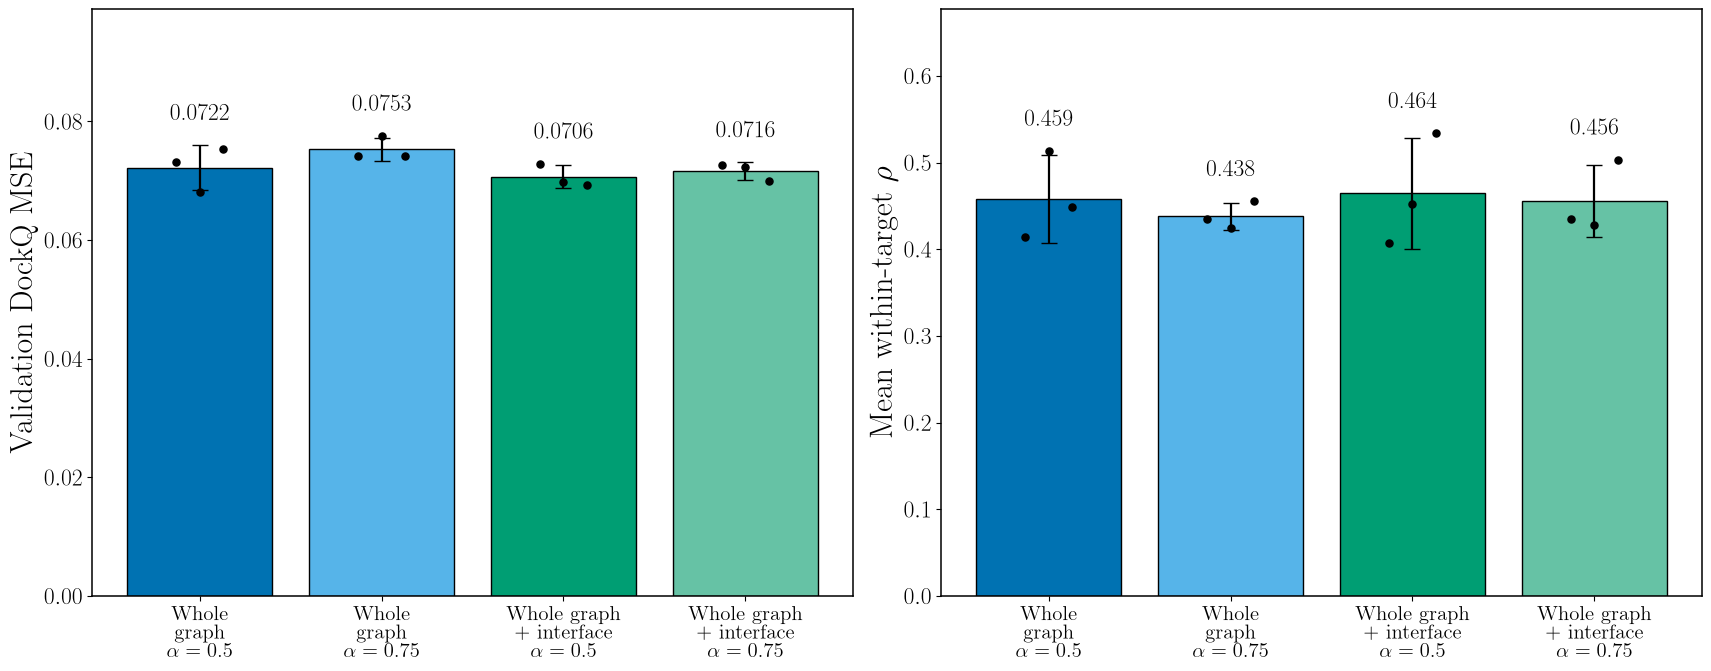

In [9]:
fig,axes=plt.subplots(1,2,figsize=(17,6.6),constrained_layout=True)
x=np.arange(len(CONFIGS)); labels=[POOL_SHORT[p]+f'\n$\\alpha={a:g}$' for p,a in CONFIGS]
for ax,column,sd_column,run_column,ylabel,fmt in [
        (axes[0],'mean_mse','seed_sd','mse','Validation DockQ MSE','%.4f'),
        (axes[1],'macro_rho','rho_sd','macro_rho',r'Mean within-target $\rho$','%.3f')]:
    values=np.array([summary.loc[c,column] for c in CONFIGS]); errors=np.array([summary.loc[c,sd_column] for c in CONFIGS])
    top=(values+errors).max()
    ax.bar(x,values,color=[CONFIG_COLOR[c] for c in CONFIGS],edgecolor='black',
           yerr=errors,capsize=6,error_kw=dict(lw=1.6))
    for i,c in enumerate(CONFIGS):
        seed_values=controls[(controls.pooling==c[0])&(controls.exponent==c[1])][run_column].to_numpy()
        ax.scatter(i+np.linspace(-.13,.13,len(seed_values)),seed_values,color='black',s=26,zorder=6)
        ax.text(i,max(values[i]+errors[i],seed_values.max())+.055*top,fmt%values[i],ha='center',fontsize=17)
    ax.set_xticks(x,labels,fontsize=15); ax.set_ylabel(ylabel)
    ax.set_ylim(0,top*1.28)
save(fig,'control_summary')

Bars are the three-seed mean with seed standard deviation; dots are the individual runs. Ranking correlation is noticeably more seed-sensitive than MSE.

## Convergence: the checkpoint arrives almost immediately

The selected epoch is where validation DockQ MSE is lowest. On the full cohort these minima occur far earlier than in the earlier 10% experiments, and validation error then rises for the remaining epochs while training error keeps falling.

In [10]:
convergence=controls.groupby(['pooling','exponent']).agg(
    mean_best_epoch=('best_epoch','mean'),min_best_epoch=('best_epoch','min'),max_best_epoch=('best_epoch','max'),
    mean_best_mse=('mse','mean'),mean_final_mse=('final_mse','mean'),mean_rebound_pct=('rebound_pct','mean'),
    mean_train_mse_at_end=('train_mse_at_end','mean'))
convergence['final_gap']=convergence.mean_final_mse-convergence.mean_train_mse_at_end
convergence.to_csv(EXPORT/'convergence.csv')
display(convergence.round(5))
print(f'Selected epochs across the twelve control runs: {sorted(controls.best_epoch)}.')
print(f'{int((controls.best_epoch<=5).sum())} of 12 runs select an epoch in the first five; '
      f'the median is {controls.best_epoch.median():.0f}.')
print(f'By epoch 50 validation MSE is {controls.rebound_pct.mean():.1f}% above the selected minimum on average, '
      f'while training MSE has fallen to {controls.train_mse_at_end.mean():.4f} '
      f'({controls.final_mse.mean()/controls.train_mse_at_end.mean():.1f}x lower than validation).')

mean_best_epoch  min_best_epoch  max_best_epoch  \
pooling  exponent                                                    
all      0.50             16.00000               2              42   
         0.75              3.00000               1               7   
combined 0.50              5.00000               2              11   
         0.75              1.66667               1               2   

                   mean_best_mse  mean_final_mse  mean_rebound_pct  \
pooling  exponent                                                    
all      0.50            0.07223         0.08434          16.37752   
         0.75            0.07533         0.08346          10.87693   
combined 0.50            0.07065         0.08751          23.90232   
         0.75            0.07162         0.08210          14.57648   

                   mean_train_mse_at_end  final_gap  
pooling  exponent                                    
all      0.50                    0.02255    0.06179  
         0.75                    0.02266    0.06080  
combined 0.50                    0.02093    0.06658  
         0.75                    0.02158    0.06051

Selected epochs across the twelve control runs: [1, 1, 1, 2, 2, 2, 2, 2, 4, 7, 11, 42].
9 of 12 runs select an epoch in the first five; the median is 2.
By epoch 50 validation MSE is 16.4% above the selected minimum on average, while training MSE has fallen to 0.0219 (3.8x lower than validation).


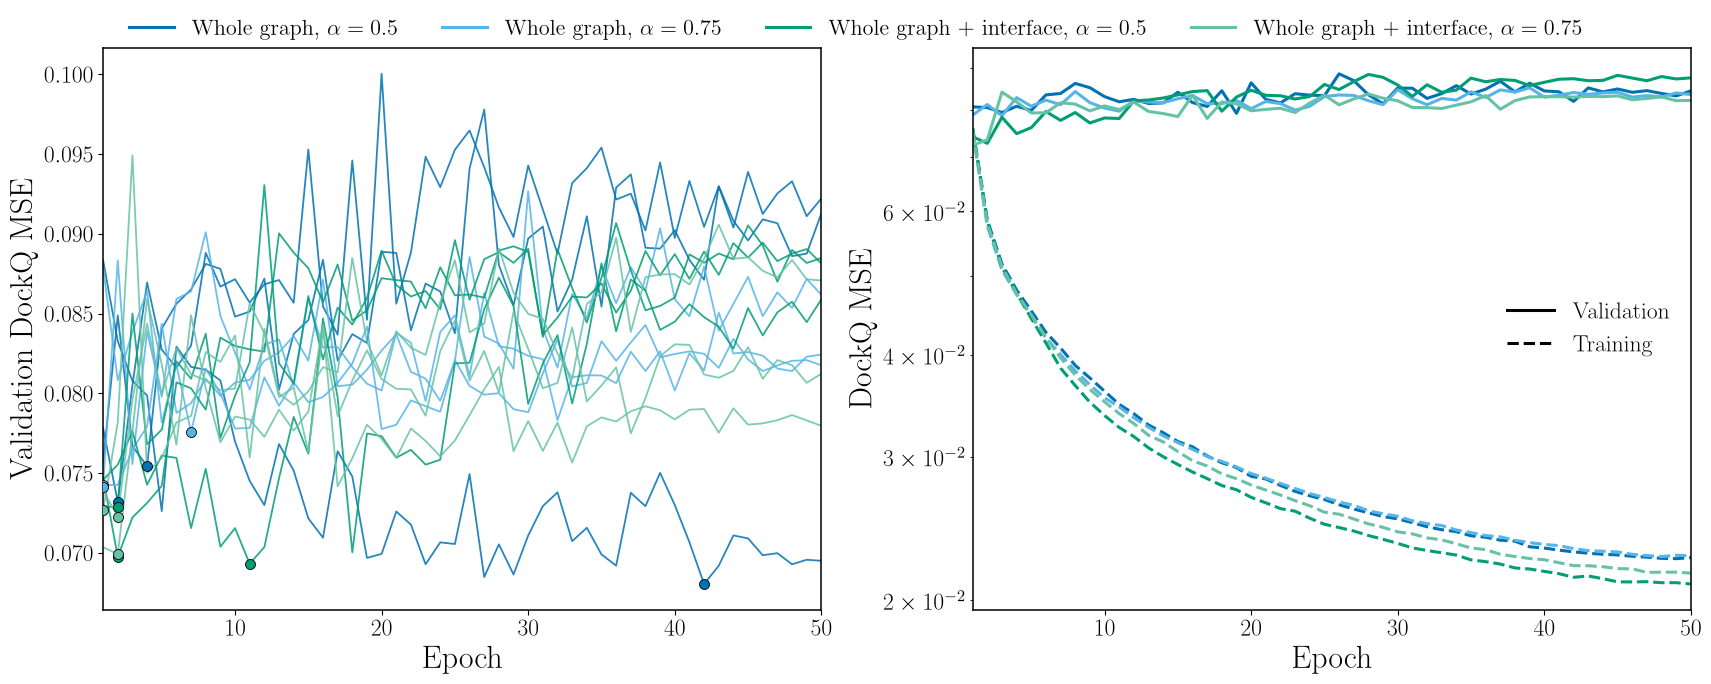

In [11]:
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
ax=axes[0]
for config in CONFIGS:
    group=[runs[n] for n in controls[(controls.pooling==config[0])&(controls.exponent==config[1])].index]
    epochs=group[0]['history'].epoch.to_numpy()
    for r in group:
        ax.plot(epochs,r['history'].val_target_mse,color=CONFIG_COLOR[config],lw=1.3,alpha=.85)
        ax.scatter(r['best_epoch'],r['pooled_mse'],color=CONFIG_COLOR[config],s=52,zorder=6,
                   edgecolor='black',lw=.6)
    ax.plot([],[],color=CONFIG_COLOR[config],lw=2.2,label=CONFIG_LABEL[config])
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation DockQ MSE'); ax.set_xlim(1,50)
handles,labels_=ax.get_legend_handles_labels()
ax=axes[1]
for config in CONFIGS:
    group=[runs[n] for n in controls[(controls.pooling==config[0])&(controls.exponent==config[1])].index]
    epochs=group[0]['history'].epoch.to_numpy()
    validation=np.vstack([r['history'].val_target_mse.to_numpy() for r in group]).mean(0)
    training=np.vstack([r['history'].train_target_mse.to_numpy() for r in group]).mean(0)
    ax.plot(epochs,validation,color=CONFIG_COLOR[config],lw=2.2)
    ax.plot(epochs,training,color=CONFIG_COLOR[config],lw=2.2,ls='--')
ax.plot([],[],color='black',lw=2.2,label='Validation')
ax.plot([],[],color='black',lw=2.2,ls='--',label='Training')
ax.set_xlabel('Epoch'); ax.set_ylabel('DockQ MSE'); ax.set_xlim(1,50); ax.set_yscale('log')
ax.legend(frameon=False,loc='center right')
fig.legend(handles,labels_,loc='outside upper center',ncol=4,frameon=False,fontsize=16)
save(fig,'validation_curves')

Bands are the seed standard deviation; dots mark each run's selected epoch. Training error falls by roughly a factor of four while validation error rises — the runs are fitting the training targets, not learning something that transfers to held-out targets. Note that training loss is collected with dropout active and weights changing within the epoch, so the gap is descriptive rather than a matched evaluation.

Because the minima are this early and this shallow, the reported per-run MSE is close to a **best-of-50 selection on a single validation split**. Some of the difference between configurations is selection noise, which is a further reason not to read the ordering above as established.

## Where the error lives: DockQ ranges

The trainer records per-epoch diagnostics in five fixed DockQ bins. Bins are defined on the **true** label, and the validation split is dominated by the lowest range, so pooled MSE is largely a statement about near-incorrect models.

In [12]:
bin_rows=[]
for name,r in runs.items():
    metrics=json.loads((r['path']/'prediction_metrics.json').read_text())['validation']
    for b in metrics['bins']:
        bin_rows.append(dict(run=name,arm=r['arm'],pooling=r['pooling'],exponent=r['exponent'],seed=r['seed'],
            bin=b['bin'],n=b['n'],mse=b['mse'],bias=b['bias']))
per_bin=pd.DataFrame(bin_rows)
per_bin.to_csv(EXPORT/'per_bin.csv',index=False)
occupancy=per_bin[per_bin.run==per_bin.run.iloc[0]].set_index('bin').n
control_bins=per_bin[per_bin.arm=='Control'].groupby(['pooling','exponent','bin']).agg(
    mse=('mse','mean'),bias=('bias','mean'))
display(pd.DataFrame({'validation_graphs':occupancy.values,
    'share_pct':100*occupancy.values/occupancy.sum()},index=BIN_LABEL).round(2))
display(control_bins.unstack('bin').round(4))
share=100*occupancy.iloc[0]/occupancy.sum()
print(f'{share:.1f}% of validation graphs lie in {BIN_LABEL[0]}.')
print('Every control configuration over-predicts the lowest range and under-predicts the highest: '
      f'mean bias {control_bins.bias.unstack("bin")[0].mean():+.3f} in {BIN_LABEL[0]} and '
      f'{control_bins.bias.unstack("bin")[4].mean():+.3f} in {BIN_LABEL[4]}.')

,validation_graphs,share_pct
0--0.2,5311,46.90
0.2--0.4,1761,15.55
0.4--0.6,1417,12.51
0.6--0.8,1504,13.28
0.8--1.0,1332,11.76


mse                                    bias          \
bin                     0       1       2       3       4       0       1   
pooling  exponent                                                           
all      0.50      0.0404  0.0370  0.0600  0.1141  0.2115  0.1582 -0.0085   
         0.75      0.0477  0.0274  0.0509  0.1220  0.2222  0.1814 -0.0052   
combined 0.50      0.0602  0.0311  0.0421  0.0917  0.1711  0.2071  0.0296   
         0.75      0.0658  0.0249  0.0360  0.0900  0.1737  0.2288  0.0401   

                                           
bin                     2       3       4  
pooling  exponent                          
all      0.50     -0.1360 -0.2699 -0.4112  
         0.75     -0.1498 -0.3013 -0.4377  
combined 0.50     -0.1064 -0.2474 -0.3793  
         0.75     -0.1040 -0.2497 -0.3840

46.9% of validation graphs lie in 0--0.2.
Every control configuration over-predicts the lowest range and under-predicts the highest: mean bias +0.194 in 0--0.2 and -0.403 in 0.8--1.0.


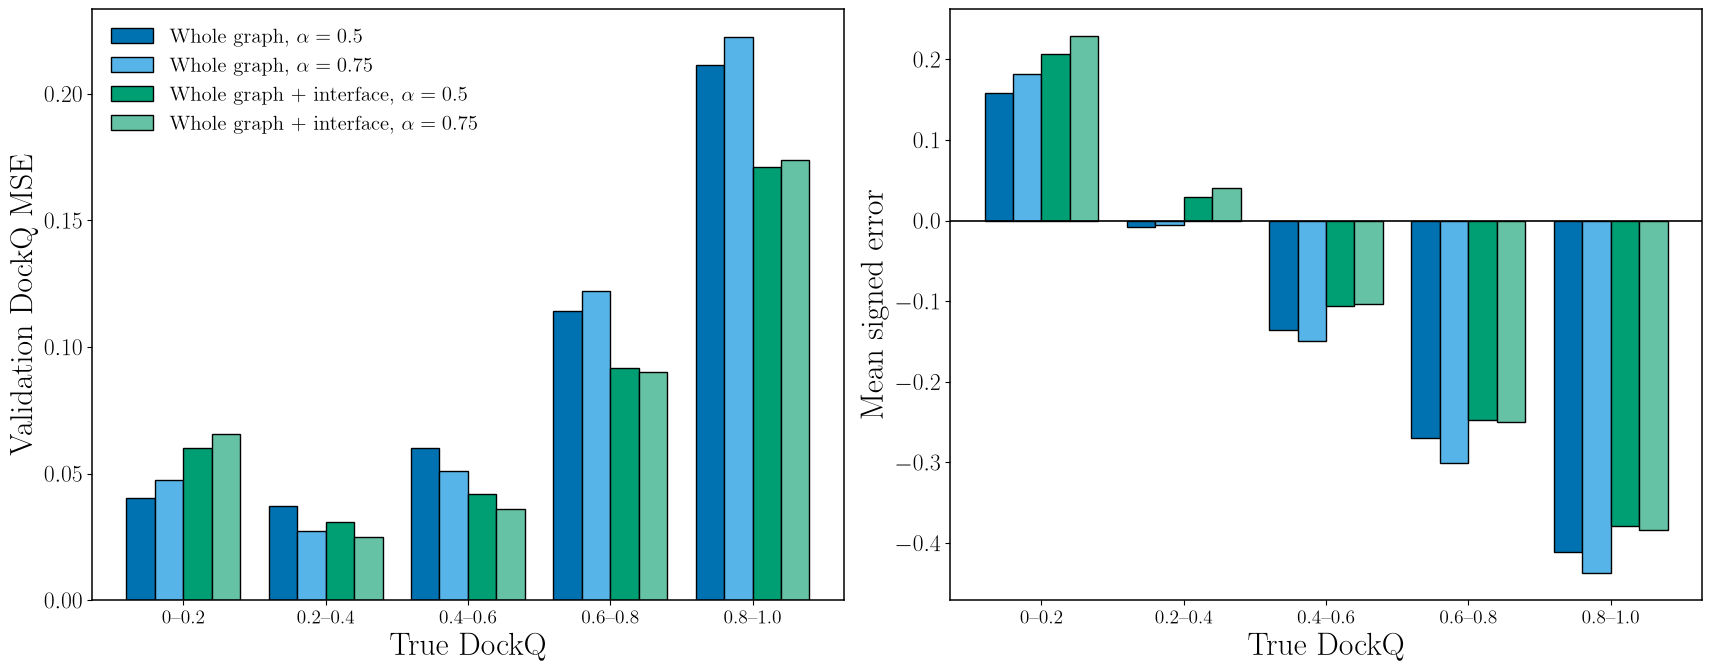

In [13]:
fig,axes=plt.subplots(1,2,figsize=(17,6.6),constrained_layout=True)
x=np.arange(5); width=.2
for ax,column,ylabel in [(axes[0],'mse','Validation DockQ MSE'),(axes[1],'bias','Mean signed error')]:
    for i,config in enumerate(CONFIGS):
        values=[control_bins.loc[(*config,b),column] for b in range(5)]
        ax.bar(x+(i-1.5)*width,values,width,color=CONFIG_COLOR[config],edgecolor='black',
               label=CONFIG_LABEL[config])
    ax.set_xticks(x,BIN_LABEL,fontsize=14); ax.set_xlabel('True DockQ'); ax.set_ylabel(ylabel)
    if column=='bias': ax.axhline(0,color='black',lw=1.2)
axes[0].legend(frameon=False,loc='upper left',fontsize=15)
save(fig,'control_dockq_bins')

Combined pooling's advantage is concentrated in the upper three ranges; it is slightly *worse* in the crowded lowest range. Because that range holds nearly half the validation graphs, the pooled-MSE gap understates the difference in the region that matters for ranking good models. The signed errors show the familiar compression: predictions are pulled toward the middle from both ends, and the underprediction at high DockQ is roughly twice the overprediction at low DockQ.

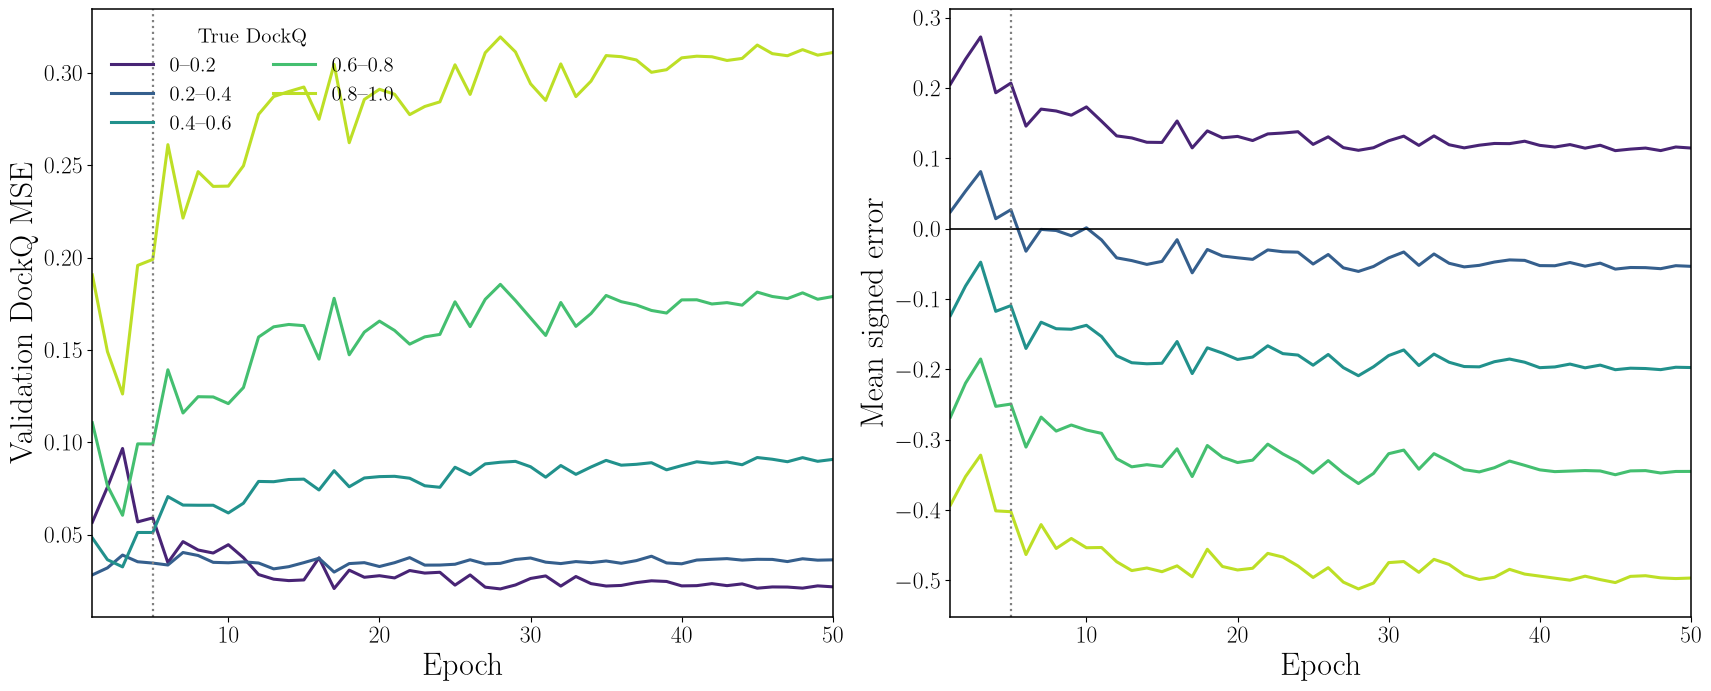

In [14]:
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
group=[runs[n] for n in controls[(controls.pooling=='combined')&(controls.exponent==.5)].index]
epochs=np.arange(1,51)
shades=plt.cm.viridis(np.linspace(.1,.9,5))
for ax,key,ylabel in [(axes[0],'mse','Validation DockQ MSE'),(axes[1],'bias','Mean signed error')]:
    for b in range(5):
        curves=np.vstack([[e['validation']['bins'][b][key] for e in r['epoch_metrics']] for r in group])
        ax.plot(epochs,curves.mean(0),color=shades[b],lw=2.2,label=BIN_LABEL[b])
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_xlim(1,50)
    if key=='bias': ax.axhline(0,color='black',lw=1.2)
selected=np.mean([r['best_epoch'] for r in group])
for ax in axes: ax.axvline(selected,color='gray',ls=':',lw=1.6)
axes[0].legend(frameon=False,loc='upper left',ncol=2,fontsize=15,title='True DockQ',title_fontsize=15)
save(fig,'bin_trajectories')

In [15]:
trajectory=[]
for b in range(5):
    curves=np.vstack([[e['validation']['bins'][b]['mse'] for e in r['epoch_metrics']] for r in group])
    bias=np.vstack([[e['validation']['bins'][b]['bias'] for e in r['epoch_metrics']] for r in group])
    trajectory.append(dict(bin=BIN_LABEL[b],n=int(occupancy[b]),first_mse=curves.mean(0)[0],
        selected_mse=curves.mean(0)[int(np.mean([r['best_epoch'] for r in group]))-1],
        final_mse=curves.mean(0)[-1],final_minus_first=curves.mean(0)[-1]-curves.mean(0)[0],
        first_bias=bias.mean(0)[0],final_bias=bias.mean(0)[-1]))
trajectory=pd.DataFrame(trajectory).set_index('bin')
trajectory['contribution_to_final_change']=(trajectory.final_minus_first*trajectory.n/trajectory.n.sum())
trajectory.to_csv(EXPORT/'bin_trajectories.csv')
display(trajectory.round(4))
improving=trajectory[trajectory.final_minus_first<0]
print(f'Over fifty epochs the lowest range improves by {-trajectory.final_minus_first.iloc[0]:.4f} '
      f'while {BIN_LABEL[4]} worsens by {trajectory.final_minus_first.iloc[4]:.4f}.')
print(f'Only {len(improving)} of 5 ranges improves; the rest degrade, and their combined weight is enough to '
      'raise pooled MSE after the first few epochs.')

,n,first_mse,selected_mse,final_mse,final_minus_first,first_bias,final_bias,contribution_to_final_change
bin,,,,,,,,
0--0.2,5311,0.0567,0.0590,0.0217,-0.0350,0.2055,0.1147,-0.0164
0.2--0.4,1761,0.0282,0.0346,0.0363,0.0082,0.0240,-0.0535,0.0013
0.4--0.6,1417,0.0482,0.0511,0.0907,0.0425,-0.1234,-0.1973,0.0053
0.6--0.8,1504,0.1105,0.0990,0.1789,0.0683,-0.2677,-0.3450,0.0091
0.8--1.0,1332,0.1906,0.1989,0.3110,0.1204,-0.3928,-0.4965,0.0142


Over fifty epochs the lowest range improves by 0.0350 while 0.8--1.0 worsens by 0.1204.
Only 1 of 5 ranges improves; the rest degrade, and their combined weight is enough to raise pooled MSE after the first few epochs.


This is the mechanism behind the very early checkpoints. Continued training keeps improving the crowded low-DockQ range — where predictions can be pushed toward the bulk of the labels — while steadily worsening every range above 0.4, with the negative bias growing throughout. The two effects cancel within a handful of epochs, after which pooled validation MSE rises.

Read carefully, this says the later epochs are not simply "overfitting noise": they trade accuracy on good models for accuracy on bad ones. Early stopping on pooled MSE partly hides that trade rather than fixing it.

## Per-target variation

Ten validation targets is a small sample, and targets differ enormously. Per-target metrics show whether a configuration's advantage is broad or driven by a few targets.

In [16]:
control_targets=per_target[per_target.arm=='Control']
target_summary=control_targets.groupby('target').agg(
    graphs=('n','first'),mean_mse=('mse','mean'),sd_mse=('mse','std'),
    mean_rho=('rho','mean'),sd_rho=('rho','std'),mean_bias=('bias','mean')).sort_values('mean_mse')
target_summary.to_csv(EXPORT/'per_target_summary.csv')
display(target_summary.round(4))
print(f'Per-target validation MSE spans {target_summary.mean_mse.min():.4f} to '
      f'{target_summary.mean_mse.max():.4f}, a factor of {target_summary.mean_mse.max()/target_summary.mean_mse.min():.1f}.')
print(f'Within-target Spearman correlation spans {target_summary.mean_rho.min():.3f} to '
      f'{target_summary.mean_rho.max():.3f}; {int((target_summary.mean_rho<.3).sum())} of '
      f'{len(target_summary)} targets fall below 0.3.')
comparison=control_targets.pivot_table(index='target',columns=['pooling','exponent'],values='mse')
wins=(comparison[('combined',.5)]<comparison[('all',.5)]).sum()+(comparison[('combined',.75)]<comparison[('all',.75)]).sum()
print(f'Combined pooling beats whole-graph pooling in {wins}/20 target-by-exponent comparisons '
      '(seed-averaged per target).')

,graphs,mean_mse,sd_mse,mean_rho,sd_rho,mean_bias
target,,,,,,
5by8,1262,0.0281,0.0067,0.9090,0.0224,0.0574
1us7,555,0.0294,0.0048,-0.0515,0.1513,0.0311
7bxh,1177,0.0586,0.0100,0.6749,0.0678,-0.0098
1ugq,1141,0.0618,0.0105,0.8592,0.0920,0.1653
1ay7,1318,0.0677,0.0091,0.6473,0.0663,0.0304
1j2j,1264,0.0782,0.0105,0.4476,0.1060,-0.0765
1zhi,1223,0.0813,0.0092,0.0442,0.1626,-0.0899
2vdb,613,0.0888,0.0123,0.4419,0.0637,-0.0825
1kac,1449,0.0985,0.0113,0.2451,0.1136,-0.0173


Per-target validation MSE spans 0.0281 to 0.1095, a factor of 3.9.
Within-target Spearman correlation spans -0.051 to 0.909; 3 of 10 targets fall below 0.3.
Combined pooling beats whole-graph pooling in 11/20 target-by-exponent comparisons (seed-averaged per target).


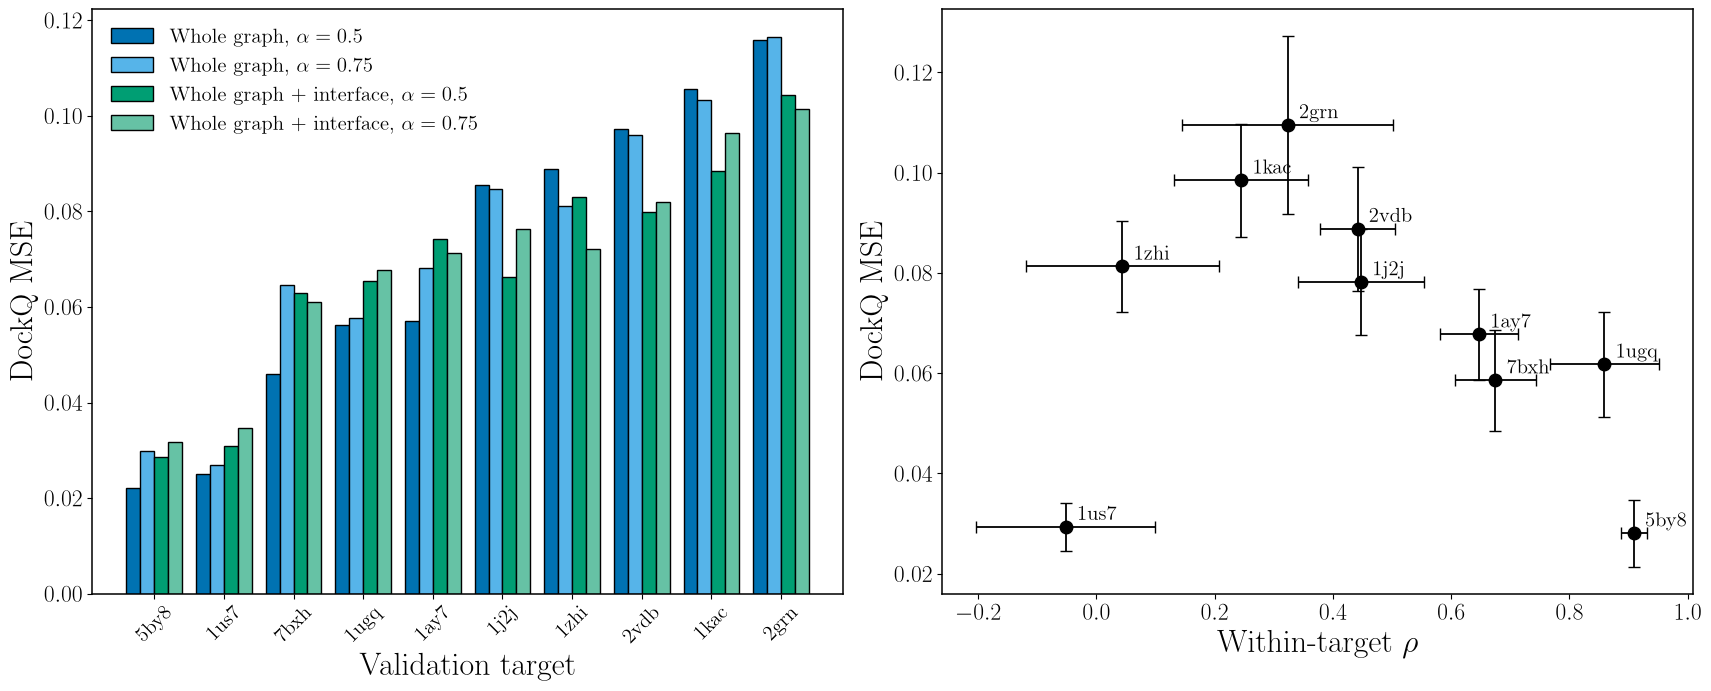

In [17]:
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
order=target_summary.index.tolist(); x=np.arange(len(order)); width=.2
ax=axes[0]
for i,config in enumerate(CONFIGS):
    values=[control_targets[(control_targets.pooling==config[0])&(control_targets.exponent==config[1])
        &(control_targets.target==t)].mse.mean() for t in order]
    ax.bar(x+(i-1.5)*width,values,width,color=CONFIG_COLOR[config],edgecolor='black',label=CONFIG_LABEL[config])
ax.set_xticks(x,order,rotation=45,fontsize=15); ax.set_xlabel('Validation target'); ax.set_ylabel('DockQ MSE')
ax.legend(frameon=False,loc='upper left',fontsize=15)
ax=axes[1]
ax.errorbar(target_summary.mean_rho,target_summary.mean_mse,xerr=target_summary.sd_rho,
            yerr=target_summary.sd_mse,fmt='o',color=CONTROL_COLOR,ms=9,capsize=4,lw=1.3)
for target,row in target_summary.iterrows():
    ax.annotate(target,(row.mean_rho,row.mean_mse),textcoords='offset points',xytext=(8,5),fontsize=15)
ax.set_xlabel(r'Within-target $\rho$'); ax.set_ylabel('DockQ MSE')
save(fig,'per_target_metrics')

Error bars are seed standard deviations across all twelve control runs. Targets with low MSE are not reliably the targets with good ranking correlation, so a configuration chosen on pooled MSE is not necessarily the one that ranks decoys best within a target.

## ESM2 additions, paired against their matched controls

Each ESM2 run has one declared `matched_control` with the same pooling, seed and exponent, trained on the same graphs. Pairing removes seed and target variation, so these deltas are the cleanest comparison available here. A negative MSE delta favours ESM2; a positive $\rho$ delta favours ESM2.

In [18]:
pairs=[]
for name,r in runs.items():
    if r['arm']!='ESM2': continue
    control=per_run.loc[r['control']]; treatment=per_run.loc[name]
    pd.testing.assert_frame_equal(
        runs[name]['predictions'][['target_id','graph_name','true_target']],
        runs[r['control']]['predictions'][['target_id','graph_name','true_target']])
    pairs.append(dict(pooling=r['pooling'],seed=r['seed'],
        mse_esm=treatment.mse,mse_control=control.mse,mse_delta=treatment.mse-control.mse,
        macro_mse_delta=treatment.macro_mse-control.macro_mse,
        macro_rho_esm=treatment.macro_rho,macro_rho_control=control.macro_rho,
        macro_rho_delta=treatment.macro_rho-control.macro_rho,
        best_epoch_esm=treatment.best_epoch,best_epoch_control=control.best_epoch,
        train_mse_esm=treatment.train_mse_at_end,train_mse_control=control.train_mse_at_end,
        rebound_esm=treatment.rebound_pct,rebound_control=control.rebound_pct))
paired=pd.DataFrame(pairs).sort_values(['pooling','seed']).reset_index(drop=True)
paired.to_csv(EXPORT/'paired_esm_deltas.csv',index=False)
display(paired.round(5))
print(f'ESM2 raises validation DockQ MSE in {int((paired.mse_delta>0).sum())}/6 matched pairs; '
      f'mean delta {paired.mse_delta.mean():+.5f} '
      f'({100*paired.mse_delta.mean()/paired.mse_control.mean():+.1f}% relative).')
print(f'Mean macro-Spearman delta {paired.macro_rho_delta.mean():+.4f}, positive in '
      f'{int((paired.macro_rho_delta>0).sum())}/6 pairs.')
print(f'Final training MSE {paired.train_mse_esm.mean():.4f} with ESM2 against '
      f'{paired.train_mse_control.mean():.4f} without '
      f'({paired.train_mse_control.mean()/paired.train_mse_esm.mean():.1f}x lower), '
      f'while the epoch-50 rebound grows from {paired.rebound_control.mean():.0f}% to '
      f'{paired.rebound_esm.mean():.0f}%.')

,pooling,seed,mse_esm,mse_control,mse_delta,macro_mse_delta,macro_rho_esm,macro_rho_control,macro_rho_delta,best_epoch_esm,best_epoch_control,train_mse_esm,train_mse_control,rebound_esm,rebound_control
0,all,7,0.07911,0.07424,0.00487,0.00479,0.44169,0.43455,0.00714,7,1,0.00701,0.02293,31.71227,16.07327
1,all,17,0.09326,0.07758,0.01568,0.01550,0.52148,0.42403,0.09745,1,7,0.00751,0.02209,46.15809,5.40015
2,all,27,0.08521,0.07416,0.01105,0.01021,0.47042,0.45533,0.01509,11,1,0.00714,0.02297,45.58049,11.15739
3,combined,7,0.08976,0.07267,0.01709,0.01677,0.40654,0.43542,-0.02888,2,1,0.00674,0.02082,38.99701,19.83321
4,combined,17,0.07916,0.07228,0.00688,0.00588,0.50407,0.42836,0.07571,4,2,0.00710,0.02179,44.79154,12.39547
5,combined,27,0.08576,0.06993,0.01583,0.01480,0.47779,0.50337,-0.02558,6,2,0.00664,0.02214,35.73988,11.50076


ESM2 raises validation DockQ MSE in 6/6 matched pairs; mean delta +0.01190 (+16.2% relative).
Mean macro-Spearman delta +0.0235, positive in 4/6 pairs.
Final training MSE 0.0070 with ESM2 against 0.0221 without (3.1x lower), while the epoch-50 rebound grows from 13% to 40%.


The direction is consistent: **ESM2 is worse on the primary metric in all six pairs**, by about 16% in relative terms, which is far larger than the seed spread within any control configuration. At the same time it fits the training data roughly three times harder and rebounds further by epoch 50 — the pattern expected when 1280 extra residue features are projected into the encoder without additional regularization.

The Spearman result points the other way and deserves separate treatment rather than being averaged away with the MSE.

In [19]:
esm_targets=per_target[per_target.arm=='ESM2'].set_index(['run','target'])
control_index=per_target[per_target.arm=='Control'].set_index(['run','target'])
rows=[]
for name,r in runs.items():
    if r['arm']!='ESM2': continue
    for target in sorted(validation_targets):
        treatment=esm_targets.loc[(name,target)]; control=control_index.loc[(r['control'],target)]
        rows.append(dict(pooling=r['pooling'],seed=r['seed'],target=target,n=int(treatment.n),
            mse_delta=treatment.mse-control.mse,rho_delta=treatment.rho-control.rho,
            bias_esm=treatment.bias,bias_control=control.bias))
target_deltas=pd.DataFrame(rows)
target_deltas.to_csv(EXPORT/'paired_esm_target_deltas.csv',index=False)
by_target=target_deltas.groupby('target').agg(mse_delta=('mse_delta','mean'),rho_delta=('rho_delta','mean'),
    mse_wins=('mse_delta',lambda v:int((v<0).sum())),rho_wins=('rho_delta',lambda v:int((v>0).sum())))
display(by_target.round(4))
print(f'Across {len(target_deltas)} paired target observations ESM2 lowers MSE in '
      f'{int((target_deltas.mse_delta<0).sum())} and raises rank correlation in '
      f'{int((target_deltas.rho_delta>0).sum())}.')
print(f'Seed-averaged, ESM2 improves MSE on {int((by_target.mse_delta<0).sum())}/10 targets and '
      f'rank correlation on {int((by_target.rho_delta>0).sum())}/10.')

,mse_delta,rho_delta,mse_wins,rho_wins
target,,,,
1ay7,0.0389,0.1677,0,6
1j2j,-0.0045,0.3428,4,6
1kac,0.0143,0.0945,0,4
1ugq,-0.0510,0.0501,6,6
1us7,-0.0065,-0.0486,5,2
1zhi,0.0168,-0.0146,1,1
2grn,0.0365,-0.3892,0,1
2vdb,0.0346,0.0388,0,4
5by8,-0.0001,0.0243,2,5


Across 60 paired target observations ESM2 lowers MSE in 19 and raises rank correlation in 38.
Seed-averaged, ESM2 improves MSE on 4/10 targets and rank correlation on 6/10.


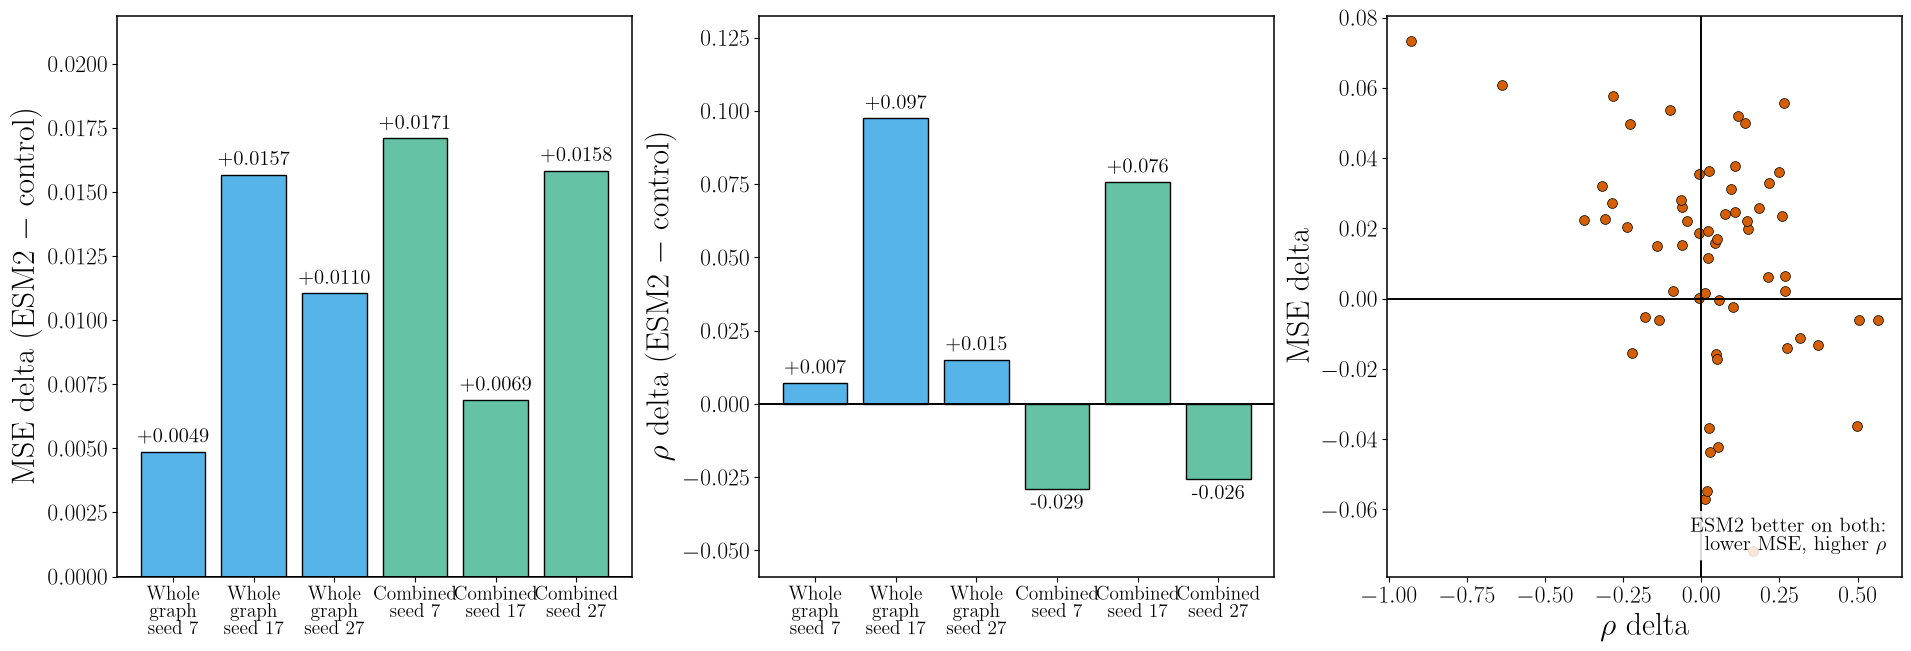

In [20]:
fig,axes=plt.subplots(1,3,figsize=(19,6.4),constrained_layout=True)
ax=axes[0]
x=np.arange(len(paired))
bars=ax.bar(x,paired.mse_delta,color=[CONFIG_COLOR[(p,.75)] for p in paired.pooling],edgecolor='black')
ax.bar_label(bars,fmt='%+.4f',padding=4,fontsize=15)
ax.axhline(0,color='black',lw=1.4)
ax.set_xticks(x,[f'{POOL_TICK[p]}\nseed {s}' for p,s in zip(paired.pooling,paired.seed)],fontsize=14)
ax.set_ylabel('MSE delta (ESM2 $-$ control)'); ax.set_ylim(0,paired.mse_delta.max()*1.28)
ax=axes[1]
bars=ax.bar(x,paired.macro_rho_delta,color=[CONFIG_COLOR[(p,.75)] for p in paired.pooling],edgecolor='black')
ax.bar_label(bars,fmt='%+.3f',padding=4,fontsize=15)
ax.axhline(0,color='black',lw=1.4)
ax.set_xticks(x,[f'{POOL_TICK[p]}\nseed {s}' for p,s in zip(paired.pooling,paired.seed)],fontsize=14)
ax.set_ylabel(r'$\rho$ delta (ESM2 $-$ control)')
lo,hi=paired.macro_rho_delta.min(),paired.macro_rho_delta.max()
ax.set_ylim(lo-.03,hi+.035)
ax=axes[2]
ax.scatter(target_deltas.rho_delta,target_deltas.mse_delta,s=50,color=ESM_COLOR,edgecolor='black',lw=.5)
ax.axhline(0,color='black',lw=1.4); ax.axvline(0,color='black',lw=1.4)
ax.set_xlabel(r'$\rho$ delta'); ax.set_ylabel('MSE delta')
ax.text(.97,.04,'ESM2 better on both:\nlower MSE, higher $\\rho$',transform=ax.transAxes,
        va='bottom',ha='right',fontsize=15,
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='none',alpha=.85))
save(fig,'esm_paired_deltas')

Each point in the right panel is one validation target in one matched pair. Most sit above the horizontal axis (worse MSE) and to the right of the vertical axis (better ranking). That combination is what a **calibration** failure looks like rather than a representation failure: the ESM2 runs order decoys within a target at least as well, sometimes distinctly better, but place them on the wrong part of the DockQ scale.

mse                                    bias          \
bin                    0       1       2       3       4       0       1   
arm     pooling                                                            
Control all       0.0477  0.0274  0.0509  0.1220  0.2222  0.1814 -0.0052   
        combined  0.0658  0.0249  0.0360  0.0900  0.1737  0.2288  0.0401   
ESM2    all       0.0155  0.0226  0.0848  0.1958  0.3271  0.1019 -0.1012   
        combined  0.0182  0.0193  0.0794  0.1890  0.3259  0.1151 -0.0966   

                                          
bin                    2       3       4  
arm     pooling                           
Control all      -0.1498 -0.3013 -0.4377  
        combined -0.1040 -0.2497 -0.3840  
ESM2    all      -0.2457 -0.3947 -0.5261  
        combined -0.2456 -0.3938 -0.5316

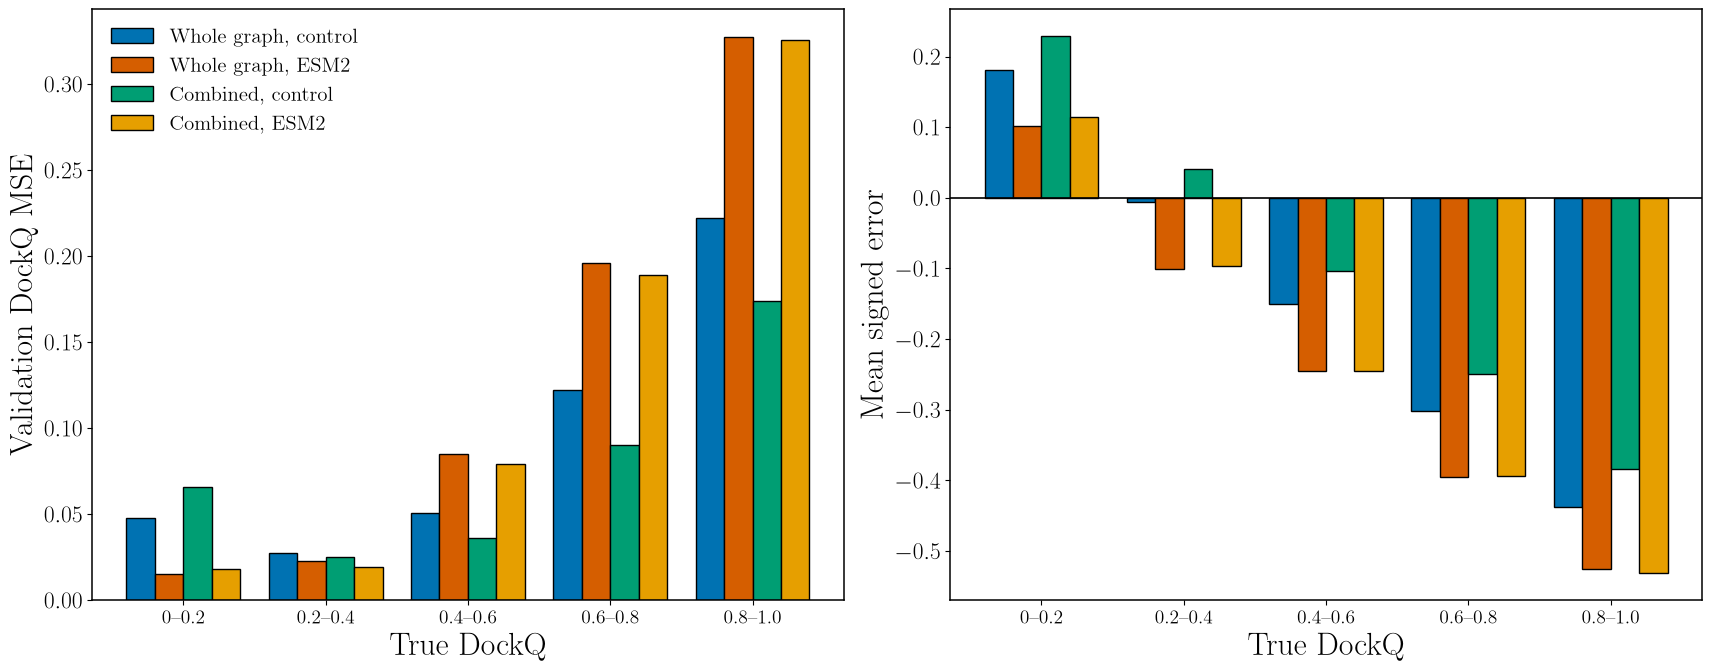

In [21]:
esm_bins=per_bin[per_bin.exponent==.75].groupby(['arm','pooling','bin']).agg(mse=('mse','mean'),bias=('bias','mean'))
display(esm_bins.unstack('bin').round(4))
fig,axes=plt.subplots(1,2,figsize=(17,6.6),constrained_layout=True)
x=np.arange(5); width=.2
styles=[('Control','all','#0072B2','Whole graph, control'),('ESM2','all',ESM_COLOR,'Whole graph, ESM2'),
        ('Control','combined','#009E73','Combined, control'),('ESM2','combined','#E69F00','Combined, ESM2')]
for ax,column,ylabel in [(axes[0],'mse','Validation DockQ MSE'),(axes[1],'bias','Mean signed error')]:
    for i,(arm,pooling,color,label) in enumerate(styles):
        values=[esm_bins.loc[(arm,pooling,b),column] for b in range(5)]
        ax.bar(x+(i-1.5)*width,values,width,color=color,edgecolor='black',label=label)
    ax.set_xticks(x,BIN_LABEL,fontsize=14); ax.set_xlabel('True DockQ'); ax.set_ylabel(ylabel)
    if column=='bias': ax.axhline(0,color='black',lw=1.2)
axes[0].legend(frameon=False,loc='upper left',fontsize=15)
save(fig,'esm_dockq_bins')

In [22]:
control_reference=esm_bins.loc[('Control',)].groupby('bin').mse.mean()
esm_reference=esm_bins.loc[('ESM2',)].groupby('bin').mse.mean()
decomposition=pd.DataFrame({'validation_graphs':occupancy.values,'control_mse':control_reference.values,
    'esm_mse':esm_reference.values},index=BIN_LABEL)
decomposition['delta']=decomposition.esm_mse-decomposition.control_mse
decomposition['contribution_to_pooled_delta']=decomposition.delta*decomposition.validation_graphs/decomposition.validation_graphs.sum()
decomposition_bias_control=float(esm_bins.loc[('Control',)].groupby('bin').bias.mean().iloc[4])
decomposition_bias_esm=float(esm_bins.loc[('ESM2',)].groupby('bin').bias.mean().iloc[4])
decomposition.to_csv(EXPORT/'esm_bin_decomposition.csv')
display(decomposition.round(5))
harmful=decomposition[decomposition.delta>0].contribution_to_pooled_delta.sum()
helpful=decomposition[decomposition.delta<0].contribution_to_pooled_delta.sum()
print(f'ESM2 improves the two lowest ranges (combined contribution {helpful:+.5f}) and worsens the three '
      f'highest ({harmful:+.5f}), for a net pooled change of {decomposition.contribution_to_pooled_delta.sum():+.5f}.')
print(f'In {BIN_LABEL[0]} ESM2 lowers the error by a factor of '
      f'{decomposition.control_mse.iloc[0]/decomposition.esm_mse.iloc[0]:.1f}; in {BIN_LABEL[4]} it raises it by '
      f'{100*(decomposition.esm_mse.iloc[4]/decomposition.control_mse.iloc[4]-1):.0f}%.')

,validation_graphs,control_mse,esm_mse,delta,contribution_to_pooled_delta
0--0.2,5311,0.05675,0.01684,-0.03991,-0.01872
0.2--0.4,1761,0.02616,0.02092,-0.00524,-0.00081
0.4--0.6,1417,0.04342,0.08210,0.03869,0.00484
0.6--0.8,1504,0.10601,0.19240,0.08639,0.01147
0.8--1.0,1332,0.19798,0.32651,0.12853,0.01512


ESM2 improves the two lowest ranges (combined contribution -0.01953) and worsens the three highest (+0.03143), for a net pooled change of +0.01190.
In 0--0.2 ESM2 lowers the error by a factor of 3.4; in 0.8--1.0 it raises it by 65%.


The decomposition makes the trade explicit. ESM2 is markedly *better* on the crowded low-DockQ ranges and clearly *worse* on everything above 0.4, with the underprediction at high DockQ deepening from about $-0.44$ to $-0.53$. Since the net effect on pooled MSE is dominated by the three upper ranges, ESM2 loses on the primary metric while sharpening exactly the behaviour that already limits these models.

A plausible reading is that the extra residue features make it easier to fit the marginal label distribution — most decoys are poor — rather than to discriminate good complexes. That is a hypothesis consistent with these diagnostics, not something this design establishes; separating it from a plain capacity/regularization effect would need ESM2 runs with stronger regularization or a matched-capacity control, which were not part of this experiment.

## Test-set predictions: what these runs do and do not contain

**None of the eighteen runs analysed above has test predictions.** All were launched with `--no-test-evaluation`, their `test_*` history columns are NaN, and their directories contain only `loss_history.csv` and `validation_predictions.csv`. Every $\rho$ reported so far is therefore a **validation** number computed on ten targets, and no test $\rho$ can be produced for the pooling or ESM2 arms without rerunning them against the sealed split on the cluster.

That matters for reading the correlations. The validation split is small and happens to contain several targets the model handles badly, so a macro $\rho$ near 0.45 is as much a statement about those ten targets as about the model. The test split holds 25 targets and 30,466 graphs, and test predictions on **the same frozen split** do exist for the earlier `full_feature_ablation_lr5e-6` experiment, which trained on the same full cohort.

Those runs are **not** the pooling runs. They use learning rate 5e-6 rather than 3e-4, dropout 0.1 rather than 0.3, no DockQ range weighting, and a smaller edge-feature set. They are the closest available full-data models on this split, and nothing below transfers a number from them to the pooling or ESM2 arms.

In [23]:
ABLATION=GATE/'full_feature_ablation_lr5e-6'
test_split=json.loads((CONTROL_ROOT/'target_splits.json').read_text())['splits']['test']
test_targets=set(test_split['targets'])
assert len(test_targets)==25
for name,r in runs.items():
    assert not (r['path']/'test_predictions.csv').exists(), name      # the sealed split really is untouched
    assert r['history'].filter(regex='^test_').isna().all().all(), name
ablation={}
rows=[]
for directory in sorted(d for d in ABLATION.iterdir() if (d/'test_predictions.csv').exists()):
    f=pd.read_csv(directory/'test_predictions.csv').sort_values(['target_id','graph_name']).reset_index(drop=True)
    assert set(f.target_id)==test_targets and len(f)==test_split['sample_count'], directory.name
    assert np.isfinite(f[['true_target','predicted_target']]).all().all()
    assert f.true_target.between(0,1).all()
    ablation[directory.name]=f
    per=[dict(run=directory.name,target=t,n=len(g),rho=rho(g.true_target,g.predicted_target),
              mse=float(np.mean((g.true_target-g.predicted_target)**2))) for t,g in f.groupby('target_id')]
    rows.append(dict(run=directory.name,n=len(f),targets=f.target_id.nunique(),
        pooled_mse=float(np.mean((f.true_target-f.predicted_target)**2)),
        macro_mse=float(np.mean([e['mse'] for e in per])),
        macro_rho=float(np.nanmean([e['rho'] for e in per])),
        median_rho=float(np.nanmedian([e['rho'] for e in per]))))
test_summary=pd.DataFrame(rows).set_index('run')
test_summary.to_csv(EXPORT/'test_summary_feature_ablation.csv')
display(test_summary.round(4))
print(f'These {len(ablation)} runs share the frozen test split: {len(test_targets)} targets, '
      f'{test_split["sample_count"]:,} graphs.')
print(f'Test macro Spearman ranges {test_summary.macro_rho.min():.3f}-{test_summary.macro_rho.max():.3f} '
      f'across the six models, against validation macro Spearman '
      f'{controls.macro_rho.min():.3f}-{controls.macro_rho.max():.3f} in the twelve pooling runs.')

,n,targets,pooled_mse,macro_mse,macro_rho,median_rho
run,,,,,,
gat2_01_rsasa_i,30466,25,0.0698,0.0696,0.6177,0.7261
gat2_02_plus_interface_node_degree,30466,25,0.0711,0.0721,0.6206,0.7530
gat2_03_plus_voronoi_contact_area,30466,25,0.0803,0.0804,0.5567,0.6771
gat4_residual_01_rsasa_i,30466,25,0.0609,0.0613,0.6481,0.7181
gat4_residual_02_plus_interface_node_degree,30466,25,0.0744,0.0756,0.6429,0.7761
gat4_residual_03_plus_voronoi_contact_area,30466,25,0.0649,0.0649,0.6317,0.7683


These 6 runs share the frozen test split: 25 targets, 30,466 graphs.
Test macro Spearman ranges 0.557-0.648 across the six models, against validation macro Spearman 0.407-0.534 in the twelve pooling runs.


### Are the correlations really that bad?

On the ten validation targets, no. The spread is wide and the mean is pulled down by a few targets, so the mean is a poor summary of the distribution.

In [24]:
PANEL_RUN='gat4_residual_03_plus_voronoi_contact_area'   # closest feature set to the pooling runs
assert PANEL_RUN in ablation
panel=ablation[PANEL_RUN]
def response_slope(g):
    return float(np.polyfit(g.true_target.to_numpy(),g.predicted_target.to_numpy(),1)[0])
test_by_target=pd.DataFrame([dict(target=t,n=len(g),rho=rho(g.true_target,g.predicted_target),
    mse=float(np.mean((g.true_target-g.predicted_target)**2)),
    slope=response_slope(g),predicted_sd=float(g.predicted_target.std()),
    true_span=float(g.true_target.max()-g.true_target.min()))
    for t,g in panel.groupby('target_id')]).sort_values('rho',ascending=False).set_index('target')
test_by_target.to_csv(EXPORT/'test_by_target.csv')
display(test_by_target.round(3))
validation_rho=per_target[per_target.arm=='Control'].groupby('target').rho.mean()
comparison=pd.DataFrame({
    'split':['Validation (12 pooling runs)','Test (feature-ablation reference)'],
    'targets':[len(validation_rho),len(test_by_target)],
    'mean_rho':[validation_rho.mean(),test_by_target.rho.mean()],
    'median_rho':[validation_rho.median(),test_by_target.rho.median()],
    'min_rho':[validation_rho.min(),test_by_target.rho.min()],
    'max_rho':[validation_rho.max(),test_by_target.rho.max()],
    'targets_below_0.3':[int((validation_rho<.3).sum()),int((test_by_target.rho<.3).sum())]}).set_index('split')
comparison.to_csv(EXPORT/'rho_split_comparison.csv')
display(comparison.round(3))
strong=int((test_by_target.rho>=.68).sum())
print(f'Test: mean rho {test_by_target.rho.mean():.3f} but median {test_by_target.rho.median():.3f}; '
      f'{strong}/25 targets reach 0.68 or better and {int((test_by_target.rho<.3).sum())} fall below 0.3.')
print('Weakest test targets: '+', '.join(f'{t} ({v:.2f})' for t,v in test_by_target.rho.tail(4).items())+'.')
print(f'Dropping those four raises the mean to {test_by_target.rho.iloc[:-4].mean():.3f}.')
print('The low means are driven by a minority of targets, not by uniformly poor ranking.')
weak=test_by_target.tail(4); strong_targets=test_by_target.iloc[:-4]
print(f'Every target spans nearly the full DockQ range ({test_by_target.true_span.min():.2f}-'
      f'{test_by_target.true_span.max():.2f}), so the weak targets are not degenerate label sets.')
print(f'Fitted predicted-on-observed slope correlates with rho at '
      f'{test_by_target.rho.corr(test_by_target.slope):.3f}: mean slope {weak.slope.mean():+.3f} for the four '
      f'weak targets against {strong_targets.slope.mean():+.3f} for the rest, with predicted SD '
      f'{weak.predicted_sd.mean():.3f} against {strong_targets.predicted_sd.mean():.3f}.')

,n,rho,mse,slope,predicted_sd,true_span
target,,,,,,
4qjf,1109,0.908,0.025,0.653,0.237,0.894
1r8o,1307,0.902,0.031,0.657,0.260,0.928
5mu7,1145,0.901,0.049,0.642,0.222,0.900
2fhz,1224,0.899,0.029,0.687,0.262,0.961
5maw,1297,0.870,0.028,0.566,0.194,0.919
8enf,1205,0.858,0.029,0.496,0.169,0.865
2ayo,869,0.856,0.029,0.557,0.188,0.856
3wdg,1345,0.833,0.032,0.558,0.206,0.920
3sgb,1304,0.801,0.060,0.377,0.165,0.913


,targets,mean_rho,median_rho,min_rho,max_rho,targets_below_0.3
split,,,,,,
Validation (12 pooling runs),10,0.454,0.445,-0.051,0.909,3
Test (feature-ablation reference),25,0.632,0.768,-0.092,0.908,4


Test: mean rho 0.632 but median 0.768; 17/25 targets reach 0.68 or better and 4 fall below 0.3.
Weakest test targets: 1buh (0.14), 4hwi (0.07), 2fju (0.02), 1gla (-0.09).
Dropping those four raises the mean to 0.745.
The low means are driven by a minority of targets, not by uniformly poor ranking.
Every target spans nearly the full DockQ range (0.83-0.96), so the weak targets are not degenerate label sets.
Fitted predicted-on-observed slope correlates with rho at 0.917: mean slope -0.005 for the four weak targets against +0.413 for the rest, with predicted SD 0.062 against 0.169.


### Twenty-five test targets, predicted against observed DockQ

One panel per test target for the reference feature-ablation model, in the format used by the seed-replicate analysis: identity line dashed, within-target Spearman $\rho$ annotated, points rasterized. Panels are ordered by $\rho$, strongest first.

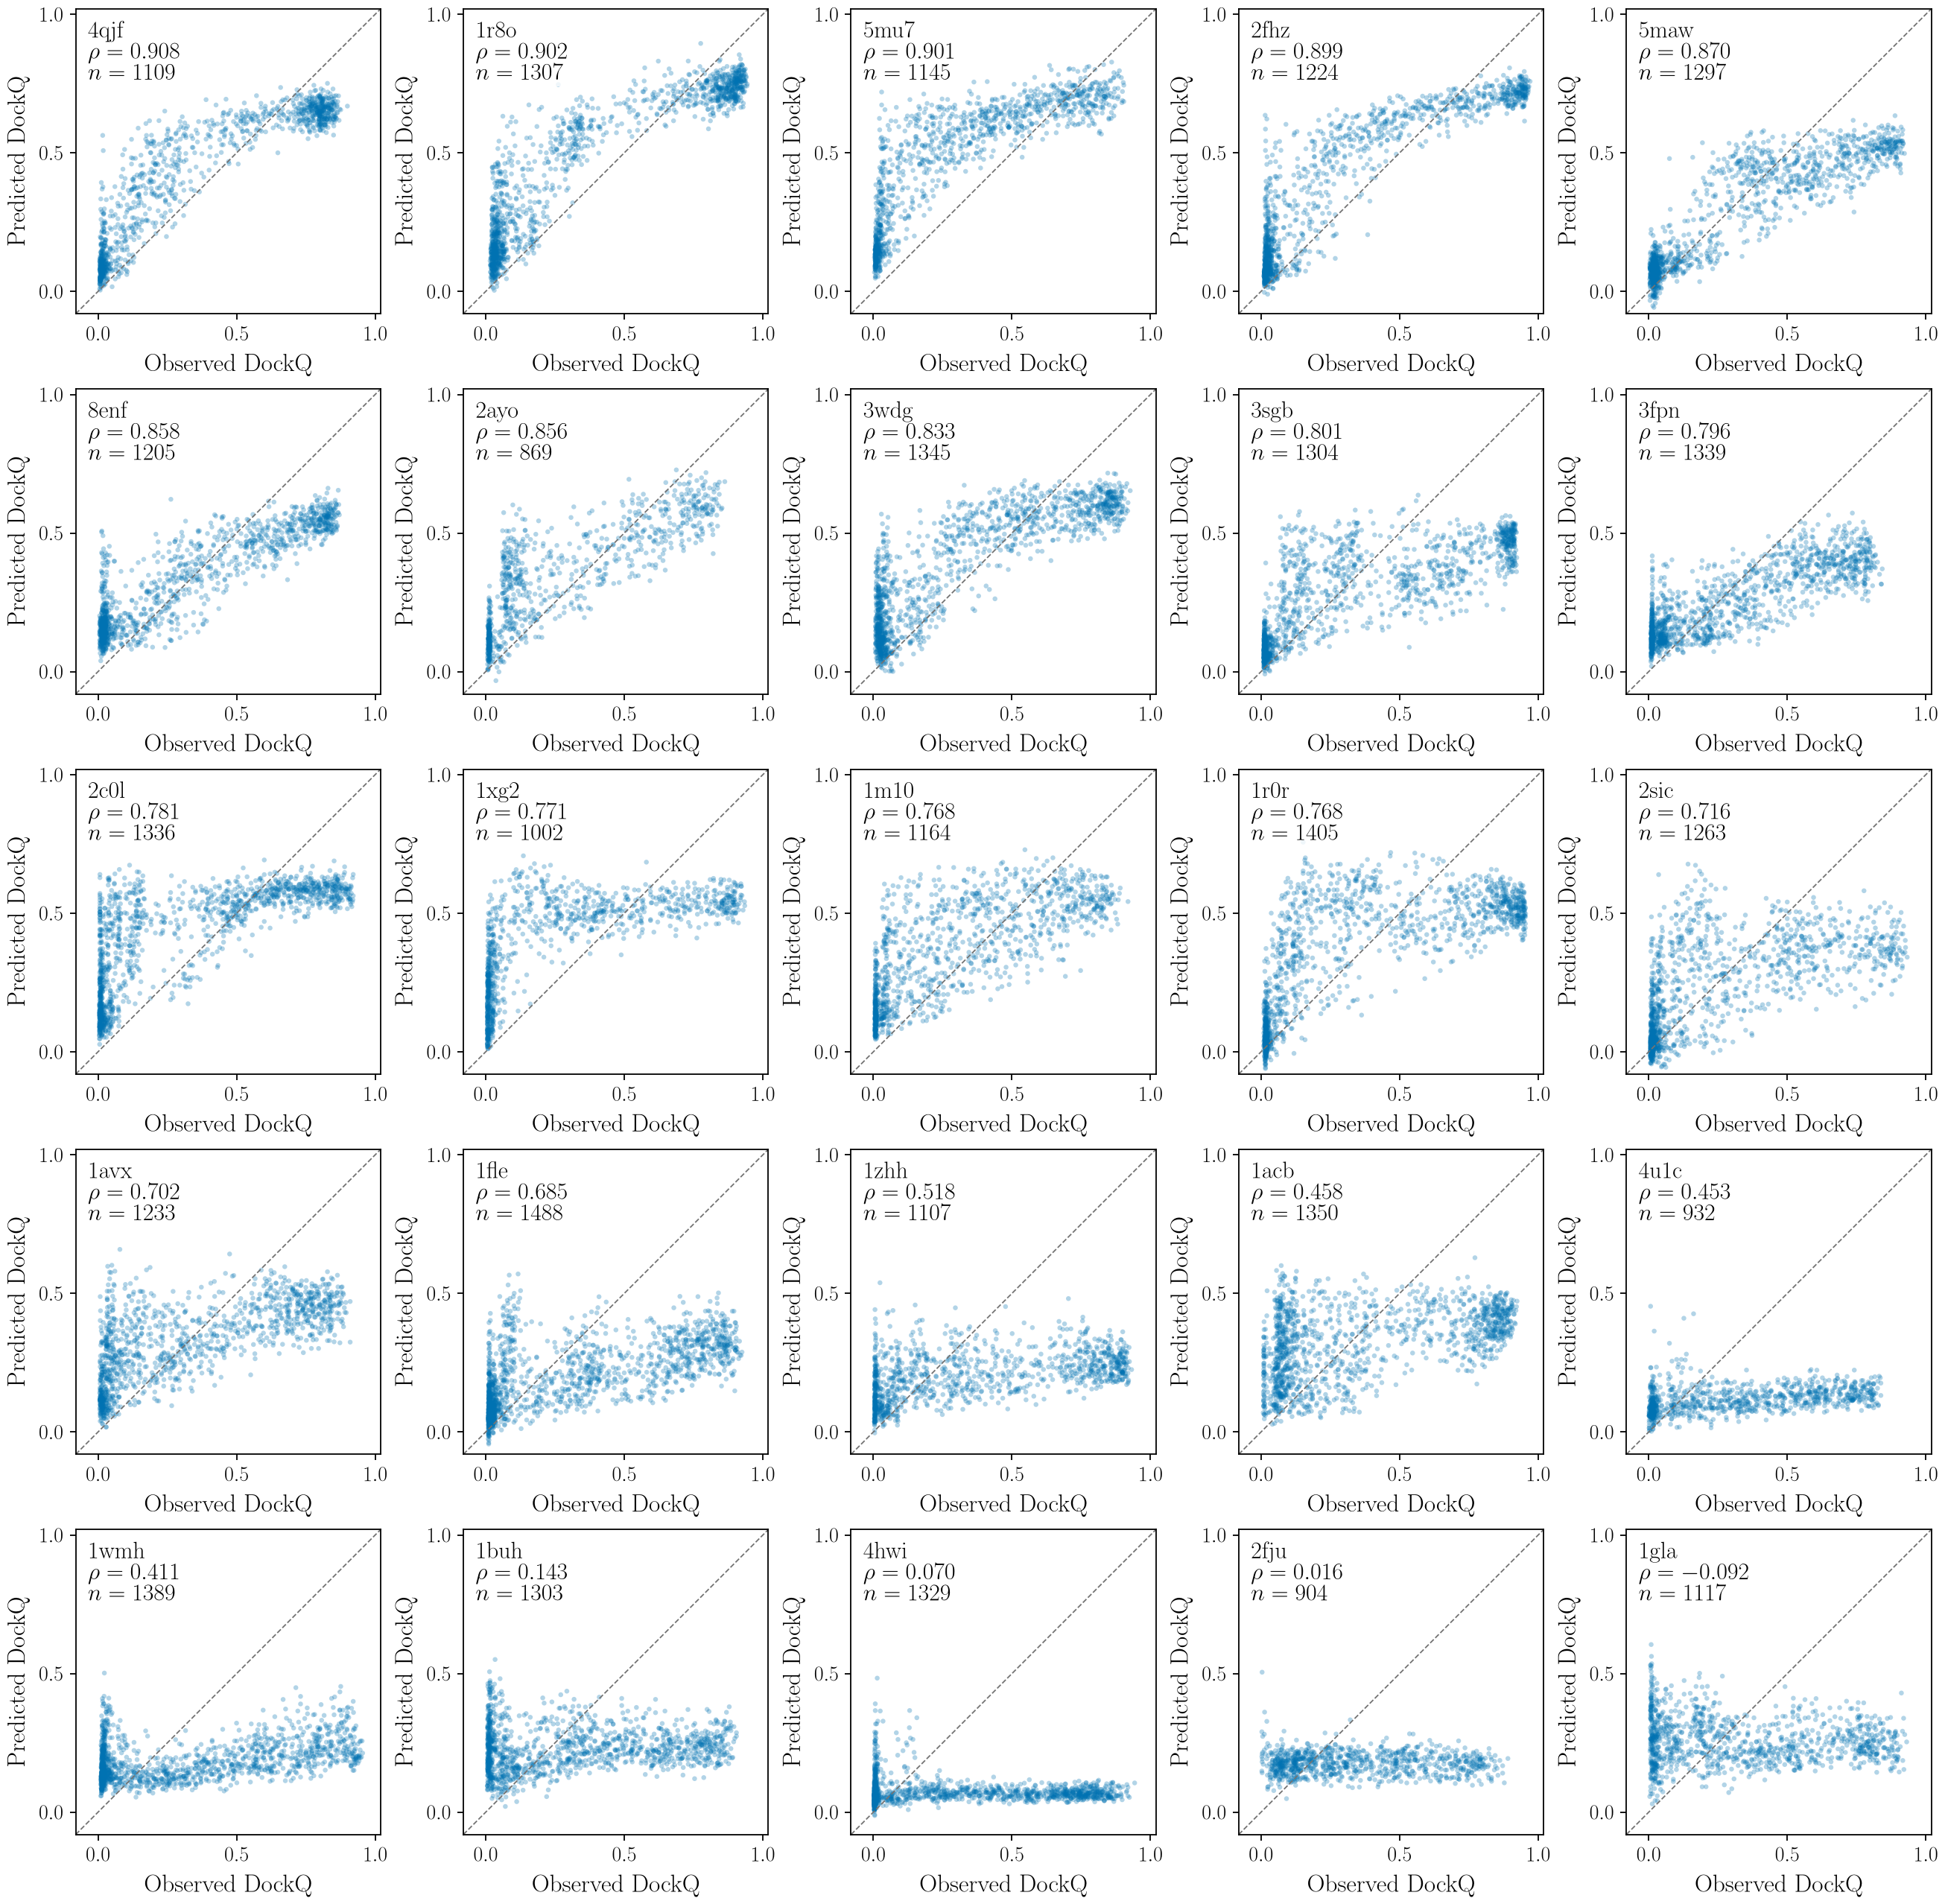

In [25]:
order=test_by_target.index.tolist()
ncols=5; nrows=int(np.ceil(len(order)/ncols))
axis_low=min(0.,panel.predicted_target.min())-.02
axis_high=max(1.,panel.predicted_target.max())+.02
with mpl.rc_context({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
        'mathtext.fontset':'cm','axes.spines.top':True,'axes.spines.right':True,
        'axes.labelsize':24,'xtick.labelsize':20,'ytick.labelsize':20}):
    fig,axes=plt.subplots(nrows,ncols,figsize=(26,5.1*nrows),sharex=True,sharey=True,constrained_layout=True)
    for ax,target in zip(np.atleast_1d(axes).flat,order):
        group=panel.loc[panel.target_id.eq(target)]
        ax.scatter(group.true_target,group.predicted_target,color='#0072B2',marker='o',alpha=.30,s=22,
                   edgecolors='none',rasterized=True)
        ax.plot([axis_low,axis_high],[axis_low,axis_high],color='0.45',ls='--',lw=1.3)
        annotation=target+'\n'+rf'$\rho = {test_by_target.loc[target,"rho"]:.3f}$'+'\n'+rf'$n = {int(test_by_target.loc[target,"n"])}$'
        ax.text(.04,.96,annotation,transform=ax.transAxes,ha='left',va='top',fontsize=23,
                bbox=dict(facecolor='white',edgecolor='none',alpha=.8,pad=2))
        ax.set(xlim=(axis_low,axis_high),ylim=(axis_low,axis_high),
               xlabel='Observed DockQ',ylabel='Predicted DockQ')
        ax.set_xticks([0,.5,1.]); ax.set_yticks([0,.5,1.])
        ax.set_aspect('equal',adjustable='box')
        ax.tick_params(labelbottom=True,labelleft=True,length=6,width=1.3,pad=6)
        ax.xaxis.labelpad=9; ax.yaxis.labelpad=9
        for spine in ax.spines.values(): spine.set_visible(True); spine.set_linewidth(1.3)
    for ax in list(np.atleast_1d(axes).flat)[len(order):]: ax.set_visible(False)
    fig.savefig(EXPORT/'test_prediction_panels.pdf',bbox_inches='tight')
    fig.savefig(EXPORT/'test_prediction_panels.png',dpi=150,bbox_inches='tight')
    plt.show()

The panels show what the aggregate $\rho$ hides, and the failure mode is specific. Every test target spans almost the whole DockQ range, so no target is a degenerate label set. What separates the strong panels from the weak ones is the **slope of predicted on observed**: it tracks $\rho$ at $r = 0.92$, averaging about $+0.41$ across the twenty-one usable targets and about $0.00$ across the four weak ones, whose predicted values scatter in a flat band with no dependence on the true score at all.

So the model does not degrade gracefully. It either produces a compressed but monotone response — slopes of roughly $0.2$--$0.7$ rather than the ideal $1$, flattening at high DockQ, which is the compression the range diagnostics already showed — or it collapses to near-constant output for that target and ranks essentially at random. The mean $\rho$ mixes these two regimes and describes neither.

A compressed monotone band still ranks decoys usefully even when MSE is poor, which is the same dissociation the ESM2 comparison showed.

### The same panels for the runs in this experiment, on validation

Ten panels, one per validation target, overlaying a pooling control with its matched ESM2 run so the ranking-versus-calibration difference is visible directly. This is the validation split; it is the only prediction set these eighteen runs contain.

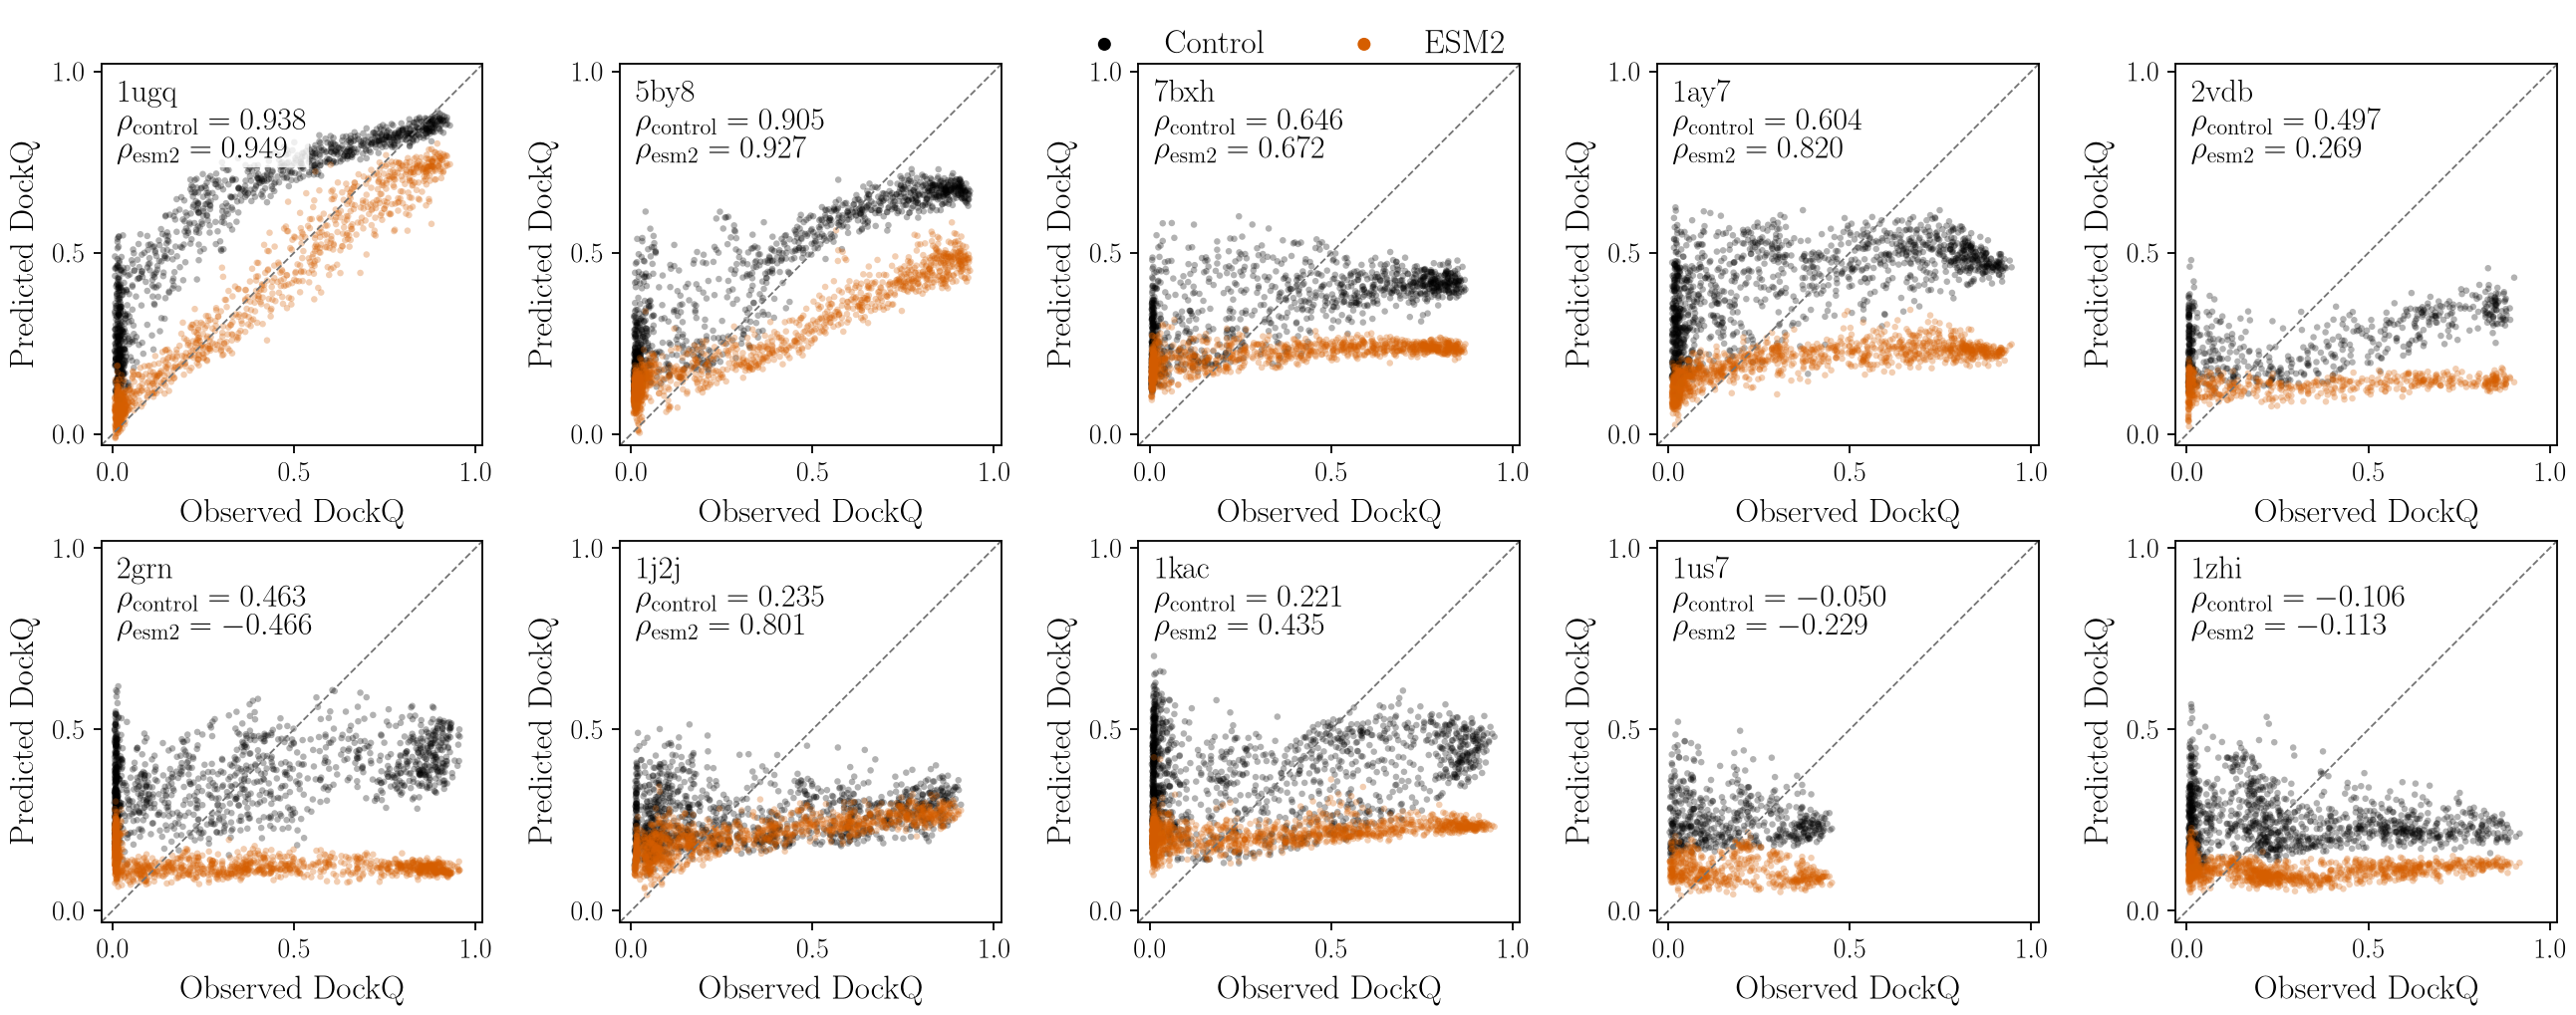

Panels: combined (whole graph + interface) pooling, seed 7, alpha=0.75; control full_combined_alpha0.75_seed7 against full_combined_alpha0.75_seed7_esm2.


In [26]:
PANEL_POOLING='combined'; PANEL_SEED=7
esm_name=next(n for n,r in runs.items() if r['arm']=='ESM2' and r['pooling']==PANEL_POOLING and r['seed']==PANEL_SEED)
control_name=runs[esm_name]['control']
overlay={'Control':(runs[control_name]['predictions'],'black'),'ESM2':(runs[esm_name]['predictions'],ESM_COLOR)}
order=per_target[(per_target.run==control_name)].sort_values('rho',ascending=False).target.tolist()
ncols=5; nrows=int(np.ceil(len(order)/ncols))
axis_low=min(0.,*(f.predicted_target.min() for f,_ in overlay.values()))-.02
axis_high=max(1.,*(f.predicted_target.max() for f,_ in overlay.values()))+.02
with mpl.rc_context({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
        'mathtext.fontset':'cm','axes.spines.top':True,'axes.spines.right':True,
        'axes.labelsize':24,'xtick.labelsize':20,'ytick.labelsize':20}):
    fig,axes=plt.subplots(nrows,ncols,figsize=(26,5.1*nrows),sharex=True,sharey=True,constrained_layout=True)
    for ax,target in zip(np.atleast_1d(axes).flat,order):
        annotation=[target]
        for label,(frame,color) in overlay.items():
            group=frame.loc[frame.target_id.eq(target)]
            ax.scatter(group.true_target,group.predicted_target,color=color,marker='o',alpha=.30,s=22,
                       edgecolors='none',rasterized=True,label=label)
            annotation.append(rf'$\rho_{{\mathrm{{{label.lower()}}}}} = {rho(group.true_target,group.predicted_target):.3f}$')
        ax.plot([axis_low,axis_high],[axis_low,axis_high],color='0.45',ls='--',lw=1.3)
        ax.text(.04,.96,'\n'.join(annotation),transform=ax.transAxes,ha='left',va='top',fontsize=23,
                bbox=dict(facecolor='white',edgecolor='none',alpha=.8,pad=2))
        ax.set(xlim=(axis_low,axis_high),ylim=(axis_low,axis_high),
               xlabel='Observed DockQ',ylabel='Predicted DockQ')
        ax.set_xticks([0,.5,1.]); ax.set_yticks([0,.5,1.])
        ax.set_aspect('equal',adjustable='box')
        ax.tick_params(labelbottom=True,labelleft=True,length=6,width=1.3,pad=6)
        ax.xaxis.labelpad=9; ax.yaxis.labelpad=9
        for spine in ax.spines.values(): spine.set_visible(True); spine.set_linewidth(1.3)
    for ax in list(np.atleast_1d(axes).flat)[len(order):]: ax.set_visible(False)
    handles,labels_=np.atleast_1d(axes).flat[0].get_legend_handles_labels()
    legend=fig.legend(handles,labels_,loc='outside upper center',ncol=2,fontsize=24,frameon=False,markerscale=2)
    for handle in legend.legend_handles: handle.set_alpha(1.)
    fig.savefig(EXPORT/'validation_prediction_panels.pdf',bbox_inches='tight')
    fig.savefig(EXPORT/'validation_prediction_panels.png',dpi=150,bbox_inches='tight')
    plt.show()
print(f'Panels: {POOL_PLAIN[PANEL_POOLING]} pooling, seed {PANEL_SEED}, alpha=0.75; '
      f'control {control_name} against {esm_name}.')

Comparing the two sets of panels is the clearest statement this analysis can make about the validation/test gap: it is not established that the pooling models would score $\rho \approx 0.45$ on the test split, because they have never been run on it. The validation targets are visibly harder as a group than the median test target. Resolving this properly means a single, pre-declared test evaluation of one chosen configuration — not repeated test looks while the protocol is still moving.

## Readout

In [27]:
best_config=summary.mean_mse.idxmin()
lines=[
 f'All 18 runs completed 50 epochs on the same {len(identity):,} validation graphs across '
 f'{identity.target_id.nunique()} targets, with identical labels and no test evaluation.',
 f'Best control configuration: {POOL_PLAIN[best_config[0]]} pooling at alpha={best_config[1]:g}, '
 f'validation DockQ MSE {summary.loc[best_config,"mean_mse"]:.5f} +/- {summary.loc[best_config,"seed_sd"]:.5f} (seed SD).',
 f'The spread across all four configurations ({summary.mean_mse.max()-summary.mean_mse.min():.5f}) is comparable to the '
 f'within-configuration seed SD ({summary.seed_sd.min():.5f}-{summary.seed_sd.max():.5f}). Combined pooling wins '
 f'{int((paired_pooling.delta<0).sum())}/6 matched pairs and is not parameter-matched '
 f'(+{size.loc[("Control","combined"),"parameters"]-base:,} parameters); the weighting exponent wins '
 f'{int((paired_exponent.delta<0).sum())}/6. Treat both as weak preferences.',
 f'Checkpoints are selected extremely early: median epoch {controls.best_epoch.median():.0f}, with '
 f'{int((controls.best_epoch<=5).sum())}/12 runs selecting epoch 5 or earlier. Validation MSE ends '
 f'{controls.rebound_pct.mean():.0f}% above its minimum while training MSE falls to '
 f'{controls.train_mse_at_end.mean():.4f}.',
 f'Training past the checkpoint keeps improving the {BIN_LABEL[0]} range and steadily degrades everything above 0.4; '
 f'the high-DockQ bias grows more negative throughout. Early stopping masks this trade rather than removing it.',
 f'ESM2 raises validation DockQ MSE in {int((paired.mse_delta>0).sum())}/6 matched pairs '
 f'({100*paired.mse_delta.mean()/paired.mse_control.mean():+.1f}% relative), while raising mean within-target Spearman '
 f'correlation by {paired.macro_rho_delta.mean():+.4f} in {int((paired.macro_rho_delta>0).sum())}/6 pairs and cutting final training MSE by '
 f'{paired.train_mse_control.mean()/paired.train_mse_esm.mean():.1f}x. Better ranking with worse calibration.',
 f'ESM2 improves the two lowest DockQ ranges and worsens the three highest; the net pooled change '
 f'({decomposition.contribution_to_pooled_delta.sum():+.5f}) comes from the upper ranges, where the underprediction '
 f'deepens from {decomposition_bias_control:+.3f} to {decomposition_bias_esm:+.3f}.',
 f'No test predictions exist for any of the 18 runs, so every rho above is validation-only on 10 targets. '
 f'On the same frozen 25-target test split, the earlier full-data feature-ablation models reach macro rho '
 f'{test_summary.macro_rho.min():.3f}-{test_summary.macro_rho.max():.3f} (median per-target rho '
 f'{test_by_target.rho.median():.3f}), with the mean pulled down by {int((test_by_target.rho<.3).sum())} weak targets. '
 'Those are different models and do not license a test claim for the pooling or ESM2 arms.',
 'On this evidence, do not adopt ESM2 for this objective as configured. The defensible next step is regularization and '
 'schedule, not more input features: these runs overfit within a handful of epochs on 109,147 training graphs.',
 'All numbers are validation-only and come from the checkpoint-selection metric itself, so they are optimistic. '
 'Three seeds and ten validation targets do not establish significance, and the test split remains sealed.']
readout='\n\n'.join(lines)
(EXPORT/'readout.md').write_text(readout+'\n')
display(Markdown(readout))

All 18 runs completed 50 epochs on the same 11,325 validation graphs across 10 targets, with identical labels and no test evaluation.

Best control configuration: combined (whole graph + interface) pooling at alpha=0.5, validation DockQ MSE 0.07065 +/- 0.00194 (seed SD).

The spread across all four configurations (0.00468) is comparable to the within-configuration seed SD (0.00148-0.00379). Combined pooling wins 5/6 matched pairs and is not parameter-matched (+4,096 parameters); the weighting exponent wins 2/6. Treat both as weak preferences.

Checkpoints are selected extremely early: median epoch 2, with 9/12 runs selecting epoch 5 or earlier. Validation MSE ends 16% above its minimum while training MSE falls to 0.0219.

Training past the checkpoint keeps improving the 0--0.2 range and steadily degrades everything above 0.4; the high-DockQ bias grows more negative throughout. Early stopping masks this trade rather than removing it.

ESM2 raises validation DockQ MSE in 6/6 matched pairs (+16.2% relative), while raising mean within-target Spearman correlation by +0.0235 in 4/6 pairs and cutting final training MSE by 3.1x. Better ranking with worse calibration.

ESM2 improves the two lowest DockQ ranges and worsens the three highest; the net pooled change (+0.01190) comes from the upper ranges, where the underprediction deepens from -0.411 to -0.529.

No test predictions exist for any of the 18 runs, so every rho above is validation-only on 10 targets. On the same frozen 25-target test split, the earlier full-data feature-ablation models reach macro rho 0.557-0.648 (median per-target rho 0.768), with the mean pulled down by 4 weak targets. Those are different models and do not license a test claim for the pooling or ESM2 arms.

On this evidence, do not adopt ESM2 for this objective as configured. The defensible next step is regularization and schedule, not more input features: these runs overfit within a handful of epochs on 109,147 training graphs.

All numbers are validation-only and come from the checkpoint-selection metric itself, so they are optimistic. Three seeds and ten validation targets do not establish significance, and the test split remains sealed.

## Limitations

- Every reported per-run number is the minimum of fifty validation evaluations and is also the checkpoint-selection criterion. It is a best-of-50 statistic on one split, not an unbiased estimate of held-out performance.
- Three seeds give a crude variance estimate. No significance test is reported, and none of the configuration differences here would survive a demanding one.
- Ten validation targets carry all the generalization signal. Per-target results vary by more than a factor of three in MSE, so target sampling dominates the uncertainty.
- Neither comparison is parameter-matched. Combined pooling adds graph-projector parameters and ESM2 adds a projection layer, so capacity is confounded with the factor of interest.
- Training-set losses are recorded with dropout active and weights changing within the epoch, so train/validation gaps are indicative rather than a matched evaluation.
- The ESM2 arm exists only at $\alpha=0.75$. Nothing here says how ESM2 would behave at $\alpha=0.5$, the better-performing exponent in the controls.
- The test split has not been touched, and it should stay that way until a protocol is fixed. Choosing among these configurations on this validation split is itself a source of optimism.